### Machine Learning Concept- Car Price Prediction
#### Ruchi Rathod - 24801180

### Importing required libraries and reading the dataset

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [2]:
# read data
df = pd.read_csv('adverts.csv') 

In [3]:
df.head(2)

,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
0,202006039777689,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970,SUV,False,Petrol Plug-in Hybrid
1,202007020778260,108230.0,61,Blue,Jaguar,XF,USED,2011.0,7000,Saloon,False,Diesel


### Exploring dataset for better Understanding

In [4]:
df.columns

Index(['public_reference', 'mileage', 'reg_code', 'standard_colour',
       'standard_make', 'standard_model', 'vehicle_condition',
       'year_of_registration', 'price', 'body_type', 'crossover_car_and_van',
       'fuel_type'],
      dtype='object')

In [5]:
df.dtypes 

public_reference           int64
mileage                  float64
reg_code                  object
standard_colour           object
standard_make             object
standard_model            object
vehicle_condition         object
year_of_registration     float64
price                      int64
body_type                 object
crossover_car_and_van       bool
fuel_type                 object
dtype: object

In [6]:
def get_unique(dataframe, column_name):
    col = dataframe[column_name][:5] 
    check_unique = print(f"The unique values in column {column_name} are {col.unique()}")  # creating a function to get upto unique values of each columns in dataset
    return check_unique  

In [7]:
reg_code_unique = get_unique(df, 'reg_code')    # printing unique values of different columns to understand the dataset
colour_unique = get_unique(df, 'standard_colour')
make_unique = get_unique(df, 'standard_make')
model_unique = get_unique(df, 'standard_model')
vehicle_condition_unique = get_unique(df, 'vehicle_condition')
body_type_unique = get_unique(df, 'body_type')
fuel_type_unique = get_unique(df, 'fuel_type')  

The unique values in column reg_code are [nan '61' '17' '16' '64']
The unique values in column standard_colour are ['Grey' 'Blue' 'Brown']
The unique values in column standard_make are ['Volvo' 'Jaguar' 'SKODA' 'Vauxhall' 'Land Rover']
The unique values in column standard_model are ['XC90' 'XF' 'Yeti' 'Mokka' 'Range Rover Sport']
The unique values in column vehicle_condition are ['NEW' 'USED']
The unique values in column body_type are ['SUV' 'Saloon' 'Hatchback']
The unique values in column fuel_type are ['Petrol Plug-in Hybrid' 'Diesel' 'Petrol']


### Data Wrangling 

In [8]:
# Lets create a copy of original dataset on which we will be working 
car_df = df.copy()
car_df.head(3)

,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
0,202006039777689,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970,SUV,False,Petrol Plug-in Hybrid
1,202007020778260,108230.0,61,Blue,Jaguar,XF,USED,2011.0,7000,Saloon,False,Diesel
2,202007020778474,7800.0,17,Grey,SKODA,Yeti,USED,2017.0,14000,SUV,False,Petrol


In [9]:
# check shape of dataset
car_df.shape

(402005, 12)

- Steps: 
1. We will perform basic data manipulation operation to inspect the dataset.
2. We will check for missing values and errant within the data, also undetstand how to handle them.
3. We will plot the required visualizations for understanding the relations between dataset columns, finding missing points with ease.

In [10]:
car_df.head(10)

,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
0,202006039777689,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970,SUV,False,Petrol Plug-in Hybrid
1,202007020778260,108230.0,61,Blue,Jaguar,XF,USED,2011.0,7000,Saloon,False,Diesel
2,202007020778474,7800.0,17,Grey,SKODA,Yeti,USED,2017.0,14000,SUV,False,Petrol
3,202007080986776,45000.0,16,Brown,Vauxhall,Mokka,USED,2016.0,7995,Hatchback,False,Diesel
4,202007161321269,64000.0,64,Grey,Land Rover,Range Rover Sport,USED,2015.0,26995,SUV,False,Diesel
5,202009304412074,16000.0,17,Blue,Audi,S5,USED,2017.0,29000,Convertible,False,Petrol
6,202007080998445,24075.0,17,Red,Vauxhall,Viva,USED,2017.0,5861,Hatchback,False,Petrol
7,202009244143980,99000.0,13,Bronze,Land Rover,Range Rover,USED,2013.0,24475,SUV,False,Diesel
8,202010014442611,111236.0,08,Black,Mercedes-Benz,S Class,USED,2008.0,6995,Limousine,False,Diesel
9,202006230431327,9500.0,19,White,Land Rover,Range Rover,USED,2019.0,79995,SUV,False,Diesel


- We observe that the public reference number functions as a unique identifier, similar to a primary key in a database.

In [11]:
# checking public reference column for uniqueness
car_df['public_reference'].nunique()

402005

In [12]:
car_df.dtypes

public_reference           int64
mileage                  float64
reg_code                  object
standard_colour           object
standard_make             object
standard_model            object
vehicle_condition         object
year_of_registration     float64
price                      int64
body_type                 object
crossover_car_and_van       bool
fuel_type                 object
dtype: object

**Numeric Features of the dataset:**

In [13]:
# creating a subset 
num_df = car_df[['mileage', 'year_of_registration', 'price']]
num_df.head(5)

,mileage,year_of_registration,price
0,0.0,NaN,73970
1,108230.0,2011.0,7000
2,7800.0,2017.0,14000
3,45000.0,2016.0,7995
4,64000.0,2015.0,26995


In [14]:
num_df.describe() 

,mileage,year_of_registration,price
count,401878.000000,368694.000000,4.020050e+05
mean,37743.595656,2015.006206,1.734197e+04
std,34831.724018,7.962667,4.643746e+04
min,0.000000,999.000000,1.200000e+02
25%,10481.000000,2013.000000,7.495000e+03
50%,28629.500000,2016.000000,1.260000e+04
75%,56875.750000,2018.000000,2.000000e+04
max,999999.000000,2020.000000,9.999999e+06


In [15]:
# checking the skewness to understand its inclination.
num_df.skew()

mileage                   1.451132
year_of_registration    -87.909954
price                   154.681527
dtype: float64

Highlights that the distribution of cars is generally weighted towards older, higher-mileage, and lower-priced vehicles, which is consistent with trends seen in the used car market

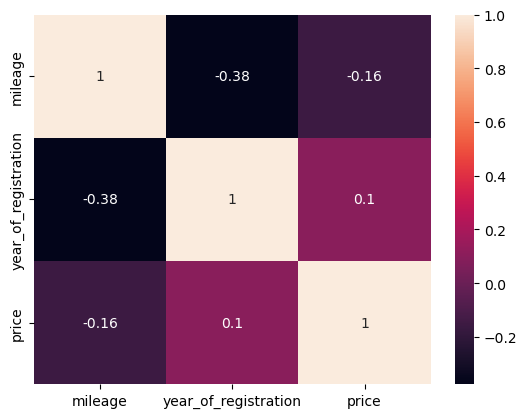

In [16]:
# Lets check the correlation of our numeric features using heatmap to understand the dependancy with price
sns.heatmap(num_df.corr(), annot=True)
plt.show()

Heatmap above shows how different factors are related, although the impact on car prices and mileage varies, and other variables like condition, model, and market demand are also crucial in determining the value of a car.

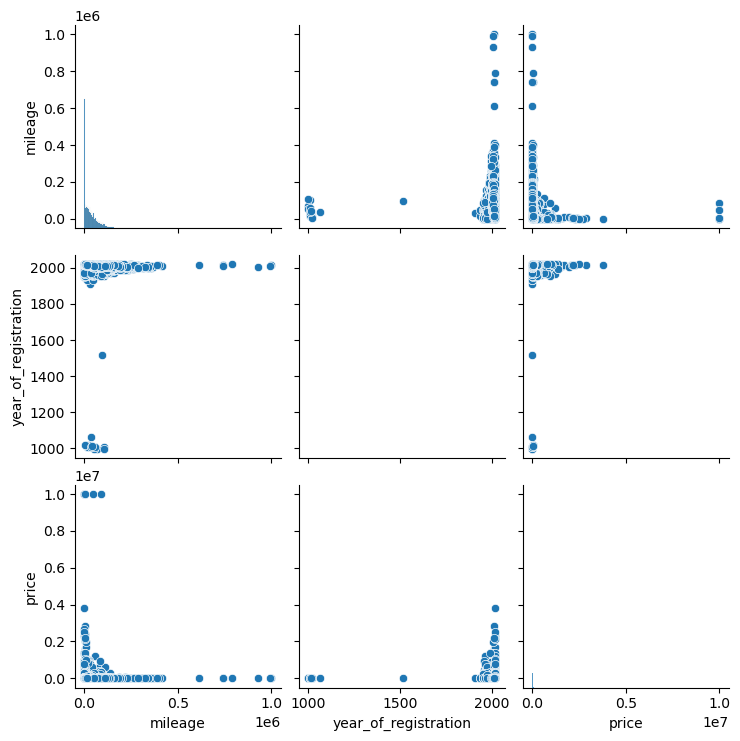

In [17]:
# visualizing the above similar thing in terms of a pairplot
sns.pairplot(num_df)
plt.show()

The relationship we can observe from above pairplot:
- price vs mileage: Higher the price means lower the mileage of the car
- price vs year_of_registration: Higher the price means higher the year of regiteration of car

2. **Categorical Features of the dataset:**

In [18]:
# creating a subset 
cat_df = car_df[[ 'reg_code', 'standard_colour', 'standard_make', 'standard_model', 
                 'vehicle_condition','body_type', 'crossover_car_and_van', 'fuel_type']]
cat_df.head(5)

,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,body_type,crossover_car_and_van,fuel_type
0,NaN,Grey,Volvo,XC90,NEW,SUV,False,Petrol Plug-in Hybrid
1,61,Blue,Jaguar,XF,USED,Saloon,False,Diesel
2,17,Grey,SKODA,Yeti,USED,SUV,False,Petrol
3,16,Brown,Vauxhall,Mokka,USED,Hatchback,False,Diesel
4,64,Grey,Land Rover,Range Rover Sport,USED,SUV,False,Diesel


In [19]:
# checking the uniques of each column
def n_uniq(dataframe):
    for column in dataframe.columns:
        nuniq_col = dataframe[column].nunique()
        print(f"Column '{column}': {nuniq_col} unique value(s)")

In [20]:
n_uniq(cat_df)

Column 'reg_code': 72 unique value(s)
Column 'standard_colour': 22 unique value(s)
Column 'standard_make': 110 unique value(s)
Column 'standard_model': 1168 unique value(s)
Column 'vehicle_condition': 2 unique value(s)
Column 'body_type': 16 unique value(s)
Column 'crossover_car_and_van': 2 unique value(s)
Column 'fuel_type': 9 unique value(s)


#### Plotting categorical data


In [21]:
# we are creating a function which can return us value counts and countplot of categorical features
def count_plot(dataframe, column_name, title, x_label, y_label):
    val_count = dataframe[column_name].value_counts()
    print(val_count)

    # Sort the column in descending order
    sort_col = val_count.sort_values(ascending=False).index
    ax = sns.countplot(
        y=dataframe[column_name], 
        order=sort_col, 
        palette="husl"  # we can replace "husl" with any other palette like "coolwarm", "pastel", "viridis" etc.
    )

    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    # display the plot
    plt.show()
    
    
# function to calculate distribution/proportion of feature values
def calculate_proportion(dataframe, column_name):
    value_proportion = dataframe[column_name].value_counts() / dataframe[column_name].count()   
    return value_proportion

Petrol                   216929
Diesel                   158120
Petrol Hybrid             13602
Petrol Plug-in Hybrid      6160
Electric                   4783
Diesel Hybrid              1403
Bi Fuel                     221
Diesel Plug-in Hybrid       185
Natural Gas                   1
Name: fuel_type, dtype: int64


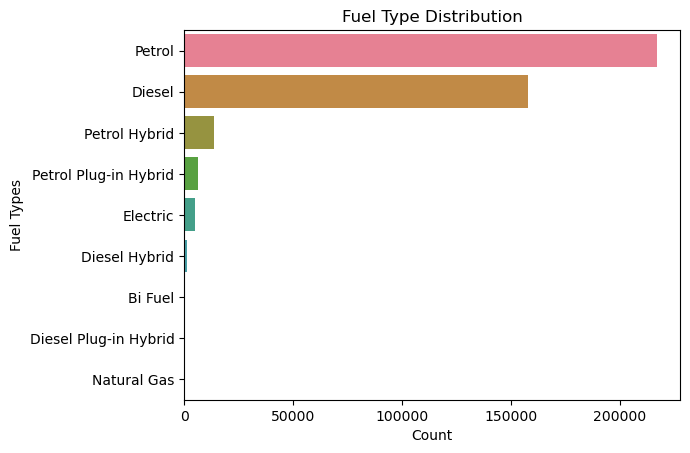

In [22]:
# Value count and countplot of fuel_type column
count_plot(cat_df, "fuel_type", "Fuel Type Distribution", "Count", "Fuel Types")

we see that petrol, diesel are most common fuel type in our dataset

In [23]:
# Getting the proportions of fuel type column
calculate_proportion(cat_df, 'fuel_type')

Petrol                   0.540426
Diesel                   0.393917
Petrol Hybrid            0.033886
Petrol Plug-in Hybrid    0.015346
Electric                 0.011916
Diesel Hybrid            0.003495
Bi Fuel                  0.000551
Diesel Plug-in Hybrid    0.000461
Natural Gas              0.000002
Name: fuel_type, dtype: float64

Hatchback          167315
SUV                115872
Saloon              36641
Estate              24692
Coupe               23258
Convertible         16038
MPV                 16026
Pickup                620
Combi Van             214
Limousine             159
Minibus               149
Camper                 77
Panel Van              61
Window Van             41
Chassis Cab             3
Car Derived Van         2
Name: body_type, dtype: int64


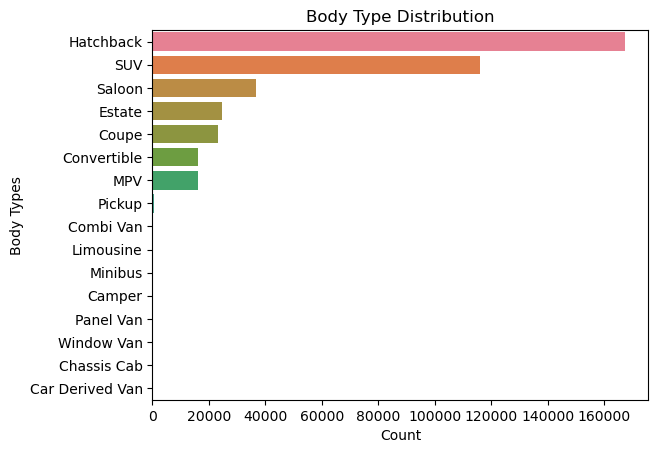

In [24]:
# Value count and countplot of body_type column
count_plot(cat_df, "body_type", "Body Type Distribution", "Count", "Body Types")

we see that Hatchback, SUV, Saloon, and Estate are most popular body type in our car dataset.

In [25]:
# Getting the proportions of body type column
calculate_proportion(cat_df, 'body_type')

Hatchback          0.417070
SUV                0.288837
Saloon             0.091336
Estate             0.061550
Coupe              0.057976
Convertible        0.039978
MPV                0.039948
Pickup             0.001545
Combi Van          0.000533
Limousine          0.000396
Minibus            0.000371
Camper             0.000192
Panel Van          0.000152
Window Van         0.000102
Chassis Cab        0.000007
Car Derived Van    0.000005
Name: body_type, dtype: float64

In [26]:
# Lets check the shape of our dataset (rows especially)
car_df.shape   

(402005, 12)

In [27]:
# Now lets check the information of dataset
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 402005 entries, 0 to 402004
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   public_reference       402005 non-null  int64  
 1   mileage                401878 non-null  float64
 2   reg_code               370148 non-null  object 
 3   standard_colour        396627 non-null  object 
 4   standard_make          402005 non-null  object 
 5   standard_model         402005 non-null  object 
 6   vehicle_condition      402005 non-null  object 
 7   year_of_registration   368694 non-null  float64
 8   price                  402005 non-null  int64  
 9   body_type              401168 non-null  object 
 10  crossover_car_and_van  402005 non-null  bool   
 11  fuel_type              401404 non-null  object 
dtypes: bool(1), float64(2), int64(2), object(7)
memory usage: 34.1+ MB


From above result we see that there are nulls available in multiple columns

### Data Cleaning (Handling Missing values, Outliers and Noise) 

#### Dropping the columns not related directly to price variation - (public_reference).

In [28]:
# drop the public reference column
car_df = car_df.drop('public_reference', axis=1)

In [29]:
# checking if it has been dropped
car_df.head(5)

,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
0,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970,SUV,False,Petrol Plug-in Hybrid
1,108230.0,61,Blue,Jaguar,XF,USED,2011.0,7000,Saloon,False,Diesel
2,7800.0,17,Grey,SKODA,Yeti,USED,2017.0,14000,SUV,False,Petrol
3,45000.0,16,Brown,Vauxhall,Mokka,USED,2016.0,7995,Hatchback,False,Diesel
4,64000.0,64,Grey,Land Rover,Range Rover Sport,USED,2015.0,26995,SUV,False,Diesel


In [30]:
# lets check the shape of our dataframe without nulls
car_df[car_df.isna().any(axis=1)].shape

(38581, 11)

In [31]:
# Checking the total number of missing values in complete dataframe
car_df.isnull().sum().sum()

72111

In [32]:
# checking nulls in each column
car_df.isnull().sum().sort_values(ascending=False) # sorted in descending to understand column with maximum nulls

year_of_registration     33311
reg_code                 31857
standard_colour           5378
body_type                  837
fuel_type                  601
mileage                    127
standard_make                0
standard_model               0
vehicle_condition            0
price                        0
crossover_car_and_van        0
dtype: int64

#### Dealing with year_of_registration feature missing values:

In [33]:
# Lets check the rows in the dataframe where both reg_code and year_of_registration is null
car_df[(car_df['year_of_registration'].isnull()) & (car_df['reg_code'].isnull())]

,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
0,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970,SUV,False,Petrol Plug-in Hybrid
17,5.0,NaN,NaN,Nissan,X-Trail,NEW,NaN,27595,SUV,False,Diesel
19,0.0,NaN,White,Volkswagen,T-Cross,NEW,NaN,25000,SUV,False,Petrol
37,0.0,NaN,White,Fiat,Panda,NEW,NaN,13999,Hatchback,False,Petrol
44,0.0,NaN,NaN,Honda,Civic,NEW,NaN,19495,Hatchback,False,Petrol
...,...,...,...,...,...,...,...,...,...,...,...
401860,10.0,NaN,Silver,Mitsubishi,Shogun Sport,NEW,NaN,31999,SUV,False,Diesel
401890,5.0,NaN,Red,BMW,Z4,NEW,NaN,47910,Convertible,False,Petrol
401902,10.0,NaN,White,BMW,3 Series,NEW,NaN,35023,Saloon,False,Petrol
401905,0.0,NaN,Red,Land Rover,Range Rover Evoque,NEW,NaN,44995,SUV,False,Petrol


In [34]:
car_df[(car_df['year_of_registration'].isnull())   #checking the number of rows with above 3 conditions, if its less than we can literally drop it 
       & (car_df['vehicle_condition'] == 'NEW') 
       & (car_df['reg_code'].isnull())]      
                                                            

,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
0,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970,SUV,False,Petrol Plug-in Hybrid
17,5.0,NaN,NaN,Nissan,X-Trail,NEW,NaN,27595,SUV,False,Diesel
19,0.0,NaN,White,Volkswagen,T-Cross,NEW,NaN,25000,SUV,False,Petrol
37,0.0,NaN,White,Fiat,Panda,NEW,NaN,13999,Hatchback,False,Petrol
44,0.0,NaN,NaN,Honda,Civic,NEW,NaN,19495,Hatchback,False,Petrol
...,...,...,...,...,...,...,...,...,...,...,...
401860,10.0,NaN,Silver,Mitsubishi,Shogun Sport,NEW,NaN,31999,SUV,False,Diesel
401890,5.0,NaN,Red,BMW,Z4,NEW,NaN,47910,Convertible,False,Petrol
401902,10.0,NaN,White,BMW,3 Series,NEW,NaN,35023,Saloon,False,Petrol
401905,0.0,NaN,Red,Land Rover,Range Rover Evoque,NEW,NaN,44995,SUV,False,Petrol


In [35]:
#dropping the rows where reg_code, year_of_registration is null and vehicle_condition is "NEW" (31249) by creating a subset using loc
car_df.drop(car_df.loc[(car_df['year_of_registration'].isnull()) 
                   & (car_df['vehicle_condition'] == 'NEW') 
                   & (car_df['reg_code'].isnull())].index, inplace=True)


In [36]:
# let check again if these rows have been dropped properly or not
car_df[(car_df['year_of_registration'].isnull()) 
       & (car_df['vehicle_condition'] == 'NEW')  & (car_df['reg_code'].isnull())]

,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type


In [37]:
car_df.shape

(370756, 11)

#### Dropping columns which makes least sense to our dataset - (vehicle_condition)

In [38]:
# Lets check how many  "USED" vehicles are there now in our dataframe car_df
car_df[car_df['vehicle_condition'] == 'USED']

,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
1,108230.0,61,Blue,Jaguar,XF,USED,2011.0,7000,Saloon,False,Diesel
2,7800.0,17,Grey,SKODA,Yeti,USED,2017.0,14000,SUV,False,Petrol
3,45000.0,16,Brown,Vauxhall,Mokka,USED,2016.0,7995,Hatchback,False,Diesel
4,64000.0,64,Grey,Land Rover,Range Rover Sport,USED,2015.0,26995,SUV,False,Diesel
5,16000.0,17,Blue,Audi,S5,USED,2017.0,29000,Convertible,False,Petrol
...,...,...,...,...,...,...,...,...,...,...,...
402000,5179.0,69,Grey,Peugeot,208,USED,2019.0,10595,Hatchback,False,Petrol
402001,110000.0,59,Red,Peugeot,107,USED,2009.0,2000,Hatchback,False,Petrol
402002,52760.0,62,White,Nissan,Qashqai,USED,2012.0,7250,SUV,False,Petrol
402003,10250.0,65,Red,Abarth,595,USED,2015.0,11490,Hatchback,False,Petrol


it is noticeable that all rows are of "USED" vehicle_condition after we have dropped the conditional rows.

In [39]:
# Lets confirm this by checking how many "NEW" vehicles are there now in our dataframe car_df
car_df[car_df['vehicle_condition'] == 'NEW']

,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type


In [40]:
# Ensuring above using counts
car_df.vehicle_condition.value_counts()

USED    370756
Name: vehicle_condition, dtype: int64

In [41]:
# dropping vehicle_condition column
car_df = car_df.drop(["vehicle_condition"], axis=1)

In [42]:
car_df.columns       #check the columns

Index(['mileage', 'reg_code', 'standard_colour', 'standard_make',
       'standard_model', 'year_of_registration', 'price', 'body_type',
       'crossover_car_and_van', 'fuel_type'],
      dtype='object')

In [43]:
#looking at the count of the rows where both 'reg_code' and 'year_of_registration' are null in car_df
car_df[(car_df['year_of_registration'].isnull()) & (car_df['reg_code'].isnull())]

,mileage,reg_code,standard_colour,standard_make,standard_model,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
1510,13406.0,NaN,White,Land Rover,Range Rover Evoque,NaN,26000,Coupe,False,Diesel
2631,1000.0,NaN,Blue,Maserati,Levante,NaN,63995,SUV,False,Petrol
4766,NaN,NaN,Grey,Subaru,Outback,NaN,35995,Estate,False,Petrol
6998,160.0,NaN,Grey,McLaren,Senna,NaN,699950,Coupe,False,Petrol
7517,11413.0,NaN,NaN,MINI,Convertible,NaN,14400,Convertible,False,Diesel
...,...,...,...,...,...,...,...,...,...,...
392499,83555.0,NaN,Black,Land Rover,Range Rover Sport,NaN,30995,SUV,False,Diesel
392730,38796.0,NaN,Grey,Rover,110,NaN,3150,Saloon,False,Petrol
396985,29000.0,NaN,Black,Lamborghini,Gallardo,NaN,77990,Coupe,False,Petrol
399728,12812.0,NaN,Silver,Rolls-Royce,Wraith,NaN,159950,Coupe,False,Petrol


In [44]:
# there are 321 rows which can not be filled using the wikipedia relation, hence we drop it now.
car_df.drop(car_df[(car_df['year_of_registration'].isnull()) 
                   & (car_df['reg_code'].isnull())].index, inplace=True)

In [45]:
# Lets re-confirm the drop was done successfully
car_df[(car_df['year_of_registration'].isnull()) & (car_df['reg_code'].isnull())]

,mileage,reg_code,standard_colour,standard_make,standard_model,year_of_registration,price,body_type,crossover_car_and_van,fuel_type


- We have observed that the price of vehicle is related to year_of_registration and not reg_code. So lets check how many values year column are null, which need to be filled using reg_code.

In [46]:
# checking for nulls in year_of_registration
car_df['year_of_registration'].isnull().sum()

1741

- We can easily now compare to reg_code and year_of_registration to fill in the nulls using wikipedia link given with our dataset.

In [47]:
car_df.head(5)

,mileage,reg_code,standard_colour,standard_make,standard_model,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
1,108230.0,61,Blue,Jaguar,XF,2011.0,7000,Saloon,False,Diesel
2,7800.0,17,Grey,SKODA,Yeti,2017.0,14000,SUV,False,Petrol
3,45000.0,16,Brown,Vauxhall,Mokka,2016.0,7995,Hatchback,False,Diesel
4,64000.0,64,Grey,Land Rover,Range Rover Sport,2015.0,26995,SUV,False,Diesel
5,16000.0,17,Blue,Audi,S5,2017.0,29000,Convertible,False,Petrol


In [48]:
# Lets take a sample subset where reg_code is 61 or 16 to built and understand the relationship between reg_code and year_of_registration
car_df[car_df['reg_code'] == '61']

,mileage,reg_code,standard_colour,standard_make,standard_model,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
1,108230.0,61,Blue,Jaguar,XF,2011.0,7000,Saloon,False,Diesel
29,73000.0,61,Grey,Toyota,Verso,2011.0,4290,MPV,False,Diesel
51,64785.0,61,Silver,Volkswagen,Polo,2011.0,4995,Hatchback,False,Diesel
52,117420.0,61,Silver,Vauxhall,Astra,2011.0,2295,Estate,False,Diesel
59,58000.0,61,White,Bentley,Continental,2011.0,39990,Coupe,False,Petrol
...,...,...,...,...,...,...,...,...,...,...
401876,45299.0,61,Blue,Jaguar,XF,2011.0,9973,Saloon,False,Diesel
401960,117000.0,61,Black,Audi,S3,2011.0,9699,Hatchback,False,Petrol
401967,93000.0,61,Black,Nissan,Juke,2011.0,4490,SUV,False,Petrol
401983,44000.0,61,White,Mazda,Mazda2,2011.0,3995,Hatchback,False,Petrol


In [49]:
# confirming again to be sure about the relationship here
car_df[car_df['reg_code'] == '16']

,mileage,reg_code,standard_colour,standard_make,standard_model,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
3,45000.0,16,Brown,Vauxhall,Mokka,2016.0,7995,Hatchback,False,Diesel
15,38603.0,16,Blue,BMW,2 Series Gran Tourer,2016.0,16000,MPV,False,Diesel
56,47000.0,16,Black,Audi,A1,2016.0,9800,Hatchback,False,Petrol
81,30909.0,16,Blue,Citroen,C1,2016.0,5695,Hatchback,False,Petrol
88,30228.0,16,White,Renault,Clio,2016.0,11999,Hatchback,False,Petrol
...,...,...,...,...,...,...,...,...,...,...
401910,40003.0,16,Black,Nissan,Juke,2016.0,8800,SUV,False,Petrol
401914,45990.0,16,Silver,Mercedes-Benz,E Class,2016.0,14100,Estate,False,Diesel
401922,66843.0,16,Silver,Mercedes-Benz,E Class,2016.0,15999,Estate,False,Diesel
401948,29337.0,16,Blue,BMW,3 Series,2016.0,15000,Estate,False,Diesel


In [50]:
# First see how many year values are there for specific reg_code (this can be done by grouping, neglecting nan)
group_reg_code_yr_dict = (
    car_df.groupby('reg_code')['year_of_registration'].apply(lambda x: list(set(x.dropna())))  # Remove NaN and duplicates
    .to_dict())

group_reg_code_yr_dict

{'02': [2019.0, 2020.0, 2002.0, 2012.0, 2013.0],
 '03': [2018.0, 2003.0],
 '04': [2018.0, 2004.0, 2006.0, 2014.0],
 '05': [2005.0, 2015.0],
 '06': [2019.0, 2020.0, 1968.0, 2006.0, 2008.0, 2015.0],
 '07': [2016.0, 2018.0, 2019.0, 1007.0, 2007.0, 2009.0, 2012.0],
 '08': [2019.0, 2020.0, 999.0, 1008.0, 2008.0, 2009.0],
 '09': [2017.0, 2019.0, 2020.0, 1909.0, 2009.0],
 '10': [1010.0, 2010.0, 2011.0, 2019.0],
 '11': [2018.0, 2011.0, 2015.0],
 '12': [2019.0, 2012.0],
 '13': [2017.0, 2018.0, 2019.0, 2020.0, 999.0, 2013.0],
 '14': [2018.0, 2019.0, 2020.0, 2014.0],
 '15': [2019.0, 2015.0],
 '16': [2016.0, 2018.0, 2019.0, 2020.0],
 '17': [2017.0, 2018.0, 2019.0, 2020.0, 1017.0],
 '18': [2018.0],
 '19': [2019.0, 2020.0],
 '20': [2020.0],
 '37': [],
 '38': [],
 '51': [1952.0, 2001.0, 2002.0, 2005.0],
 '52': [2002.0, 2003.0, 1999.0],
 '53': [2003.0, 2004.0, 2020.0, 2015.0],
 '54': [2016.0, 2004.0, 2005.0, 2006.0, 2015.0],
 '55': [2018.0, 2019.0, 1006.0, 2005.0, 2006.0],
 '56': [2020.0, 2014.0, 2006

There are a few reg_code having multiple year_of_registration, we need to fill such code with mode and create a dictionary

In [51]:
mapping_dictionary = (
    car_df.groupby('reg_code')['year_of_registration']                            # Group by 'reg_code', then apply a lambda function to get the most frequent value for each 'reg_code'
    .apply(lambda x: x.mode().iloc[0] if not x.mode().empty else None)            # Use mode, return the first mode
    .to_dict()
)

mapping_dictionary

{'02': 2002.0,
 '03': 2003.0,
 '04': 2004.0,
 '05': 2005.0,
 '06': 2006.0,
 '07': 2007.0,
 '08': 2008.0,
 '09': 2009.0,
 '10': 2010.0,
 '11': 2011.0,
 '12': 2012.0,
 '13': 2013.0,
 '14': 2014.0,
 '15': 2015.0,
 '16': 2016.0,
 '17': 2017.0,
 '18': 2018.0,
 '19': 2019.0,
 '20': 2020.0,
 '37': nan,
 '38': nan,
 '51': 2001.0,
 '52': 2002.0,
 '53': 2003.0,
 '54': 2004.0,
 '55': 2005.0,
 '56': 2006.0,
 '57': 2007.0,
 '58': 2008.0,
 '59': 2009.0,
 '60': 2010.0,
 '61': 2011.0,
 '62': 2012.0,
 '63': 2013.0,
 '64': 2014.0,
 '65': 2015.0,
 '66': 2016.0,
 '67': 2017.0,
 '68': 2018.0,
 '69': 2019.0,
 '70': 2020.0,
 '723xuu': nan,
 '85': nan,
 '94': nan,
 '95': nan,
 'A': 1984.0,
 'B': 1985.0,
 'C': 1986.0,
 'CA': nan,
 'D': 1987.0,
 'E': 1988.0,
 'F': 1989.0,
 'FW': 1934.0,
 'G': 1989.0,
 'H': 1991.0,
 'J': 1992.0,
 'K': 1992.0,
 'L': 1994.0,
 'M': 1994.0,
 'N': 1996.0,
 'P': 1997.0,
 'R': 1998.0,
 'S': 1998.0,
 'T': 1999.0,
 'V': 1999.0,
 'W': 2000.0,
 'X': 2000.0,
 'Y': 2001.0,
 'k': 1992.0,
 'm'

In [52]:
# Filling null values in 'year_of_registration' using the mapping_dictionary
car_df['year_of_registration'] = car_df['year_of_registration'].fillna(car_df['reg_code'].map(mapping_dictionary))

In [53]:
# checking the nulls left in year_of_registration after filling using above mapping_dictionary
car_df.year_of_registration.isnull().sum()

9

In [54]:
# see these rows and understand how we can fill them now
yr_of_reg_df = car_df[car_df['year_of_registration'].isnull()]
yr_of_reg_df

,mileage,reg_code,standard_colour,standard_make,standard_model,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
9940,32001.0,94,Orange,Renault,Captur,NaN,7400,SUV,False,Petrol
28559,58686.0,85,Black,Hyundai,i30,NaN,6900,NaN,False,Diesel
80899,2000.0,CA,Green,Caterham,Seven,NaN,21995,Convertible,False,Petrol
166035,4050.0,723xuu,Turquoise,Chevrolet,Corvette,NaN,89990,NaN,False,Petrol
167430,55643.0,95,Grey,Citroen,DS4,NaN,6800,Hatchback,False,Diesel
231213,61370.0,94,Black,Vauxhall,Mokka,NaN,7450,NaN,False,Diesel
265390,23157.0,38,Black,Mercedes-Benz,E Class,NaN,26550,NaN,False,Diesel
329449,39312.0,95,Silver,Renault,Captur,NaN,8000,SUV,False,Petrol
357325,31487.0,37,White,Suzuki,Baleno,NaN,6950,NaN,False,Petrol


In [55]:
yr_of_reg_df['reg_code'].unique() # taking all uniques

array(['94', '85', 'CA', '723xuu', '95', '38', '37'], dtype=object)

- we can see that ['94', '85', 'CA', '723xuu', '95', '38', '37'] are reg_code where year_of_registration is null.

In [56]:
car_df[car_df['reg_code'] == 'CA']

,mileage,reg_code,standard_colour,standard_make,standard_model,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
80899,2000.0,CA,Green,Caterham,Seven,NaN,21995,Convertible,False,Petrol


In [57]:
car_df[car_df['reg_code'] == '723xuu']

,mileage,reg_code,standard_colour,standard_make,standard_model,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
166035,4050.0,723xuu,Turquoise,Chevrolet,Corvette,NaN,89990,NaN,False,Petrol


- Final Thought: As analyzed above, we need to drop all the rows where reg_code directs to futuristic date and Code which are not available in wikipedia, viz: ['94', '85', 'CA', '723xuu', '95', '38', '37'], **basically we dropping all the rows where year_of_registration is null**.

In [58]:
# dropping all leftover nulls
car_df.drop(car_df[car_df['year_of_registration'].isnull()].index, inplace=True)

In [59]:
# checking any year_of_registration is null
car_df.year_of_registration.isnull().sum()

0

#### Dealing with reg_code feature missing values:

In [60]:
car_df['reg_code'].isnull().sum()

287

#### Dropping columns which makes least sense to our dataset - (reg_code)

In [61]:
car_df = car_df.drop(['reg_code'], axis=1)

In [62]:
car_df.head(2)

,mileage,standard_colour,standard_make,standard_model,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
1,108230.0,Blue,Jaguar,XF,2011.0,7000,Saloon,False,Diesel
2,7800.0,Grey,SKODA,Yeti,2017.0,14000,SUV,False,Petrol


In [63]:
# now again lets see the nulls present in dataframe
car_df.isnull().sum().sort_values(ascending=False)

standard_colour          4312
body_type                 717
fuel_type                 432
mileage                   115
standard_make               0
standard_model              0
year_of_registration        0
price                       0
crossover_car_and_van       0
dtype: int64

In [64]:
# checking datatypes as well
car_df.dtypes

mileage                  float64
standard_colour           object
standard_make             object
standard_model            object
year_of_registration     float64
price                      int64
body_type                 object
crossover_car_and_van       bool
fuel_type                 object
dtype: object

#### Dealing with standard_colour, body_type, fuel_type and Mileage

In [65]:
#Creating a function which can handle both the case (categorical and numeric column)
# IF-Else conditional statement: For categorical--> fill using mode & For numeric--> fill using mean

def groupwise_imputer(data, group_cols, target_col, is_categorical=True):
    if is_categorical:  #Fill with mode
        # Compute mode for each group (grouped by multiple columns)
        mode_mapping = (
            data.groupby(group_cols)[target_col]
            .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
        )
        # Map the mode values to the missing rows
        data[target_col] = data.apply(
            lambda row: mode_mapping.loc[tuple(row[group_cols])] if pd.isnull(row[target_col]) else row[target_col],
            axis=1
        )
    else:  #Fill with mean
        # Compute mean for each group (grouped by multiple columns)
        mean_mapping = data.groupby(group_cols)[target_col].transform('mean')
        # Fill missing values with the group mean
        data[target_col] = data[target_col].fillna(mean_mapping)
    
    return data


In [66]:
# total nulls in standard_colour and body_type
print(car_df['standard_colour'].isnull().sum())
print(car_df['body_type'].isnull().sum())
print(car_df['fuel_type'].isnull().sum())

4312
717
432


In [67]:
car_df.isnull().sum().sort_values(ascending=False) 

standard_colour          4312
body_type                 717
fuel_type                 432
mileage                   115
standard_make               0
standard_model              0
year_of_registration        0
price                       0
crossover_car_and_van       0
dtype: int64

In [68]:
# calling the above function to fill nulls in standard_colour and body_type
groupwise_imputer(car_df, ['standard_make', 'standard_model'], 'standard_colour', is_categorical=True)     # standard_colour
groupwise_imputer(car_df, ['standard_make', 'standard_model'], 'body_type', is_categorical=True)           # body_type
groupwise_imputer(car_df, ['standard_make', 'standard_model'], 'fuel_type', is_categorical=True)           # fuel_type

# lets re-check nulls now after using groupwise_imputer
print(car_df['standard_colour'].isnull().sum())
print(car_df['body_type'].isnull().sum())
print(car_df['fuel_type'].isnull().sum())

24
35
16


In [69]:
# lets fill this remaining 24 & 35 & 16 rows by taking only one group_cols column ['standard_make']
groupwise_imputer(car_df, ['standard_make'], 'standard_colour', is_categorical=True)
groupwise_imputer(car_df, ['standard_make'], 'body_type', is_categorical=True)
groupwise_imputer(car_df, ['standard_make'], 'fuel_type', is_categorical=True)

# lets re-check nulls now 
print(car_df['standard_colour'].isnull().sum()) 
print(car_df['body_type'].isnull().sum()) 
print(car_df['fuel_type'].isnull().sum())

2
5
0


In [70]:
car_df['standard_colour'].fillna(car_df['standard_colour'].mode()[0], inplace=True)   # filling 2 nulls in standard_colour with mode 
car_df['body_type'].fillna(car_df['body_type'].mode()[0], inplace=True)       # filling 5 nulls in body_type with mode

In [71]:
# Lets print nulls in dataframe again and then proceed ahead,
car_df.isnull().sum().sort_values(ascending=False)

mileage                  115
standard_colour            0
standard_make              0
standard_model             0
year_of_registration       0
price                      0
body_type                  0
crossover_car_and_van      0
fuel_type                  0
dtype: int64

In [72]:
num_df.corr()

,mileage,year_of_registration,price
mileage,1.000000,-0.375541,-0.160204
year_of_registration,-0.375541,1.000000,0.102341
price,-0.160204,0.102341,1.000000


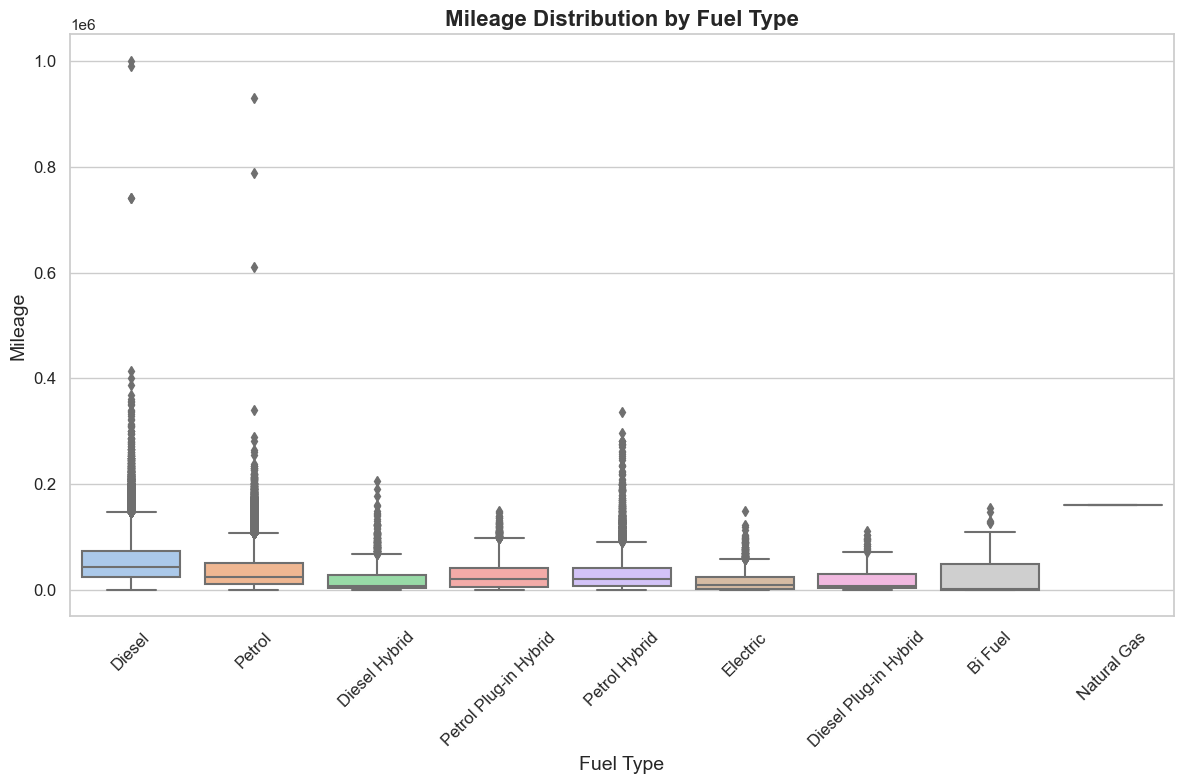

In [73]:
# plotting to check relationship between fuel_type and mileage

# Set the overall style
sns.set(style="whitegrid", palette="pastel")

# Create the plot
plt.figure(figsize=(12, 8))  
sns.boxplot(x='fuel_type', y='mileage', data=car_df)

# Add a title and labels
plt.title('Mileage Distribution by Fuel Type', fontsize=16, fontweight='bold')
plt.xlabel('Fuel Type', fontsize=14)
plt.ylabel('Mileage', fontsize=14)

# Rotate x-axis labels for better readability (if needed)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# Show the plot
plt.tight_layout() 
plt.show()


In [74]:
# calling function to fill mileage using combination of 'fuel_type' and 'year_of_registeration'
groupwise_imputer(car_df, ['year_of_registration', 'fuel_type'], 'mileage', is_categorical=True)  

# check for nulls after performing groupwise_imputer
car_df['mileage'].isnull().sum()

0

In [75]:
# lets check if we have filled all nulls
car_df.isnull().sum().sort_values(ascending=False)

mileage                  0
standard_colour          0
standard_make            0
standard_model           0
year_of_registration     0
price                    0
body_type                0
crossover_car_and_van    0
fuel_type                0
dtype: int64

- Hence, we have successfully handled all missing values in our dataset.

#### Deal with error values/ errant data available in dataset. (outliers and noise)

In [76]:
# checking the details of dataframe now
car_df.describe()

,mileage,year_of_registration,price
count,370426.000000,370426.000000,3.704260e+05
mean,40929.723432,2015.010645,1.584208e+04
std,34432.050829,7.952332,2.536314e+04
min,0.000000,999.000000,1.200000e+02
25%,14453.250000,2013.000000,6.999000e+03
50%,31865.000000,2016.000000,1.189000e+04
75%,60000.000000,2018.000000,1.850000e+04
max,999999.000000,2020.000000,3.799995e+06


- Plotting distribution and outliers in the year_of_registration, mileage, and price columns

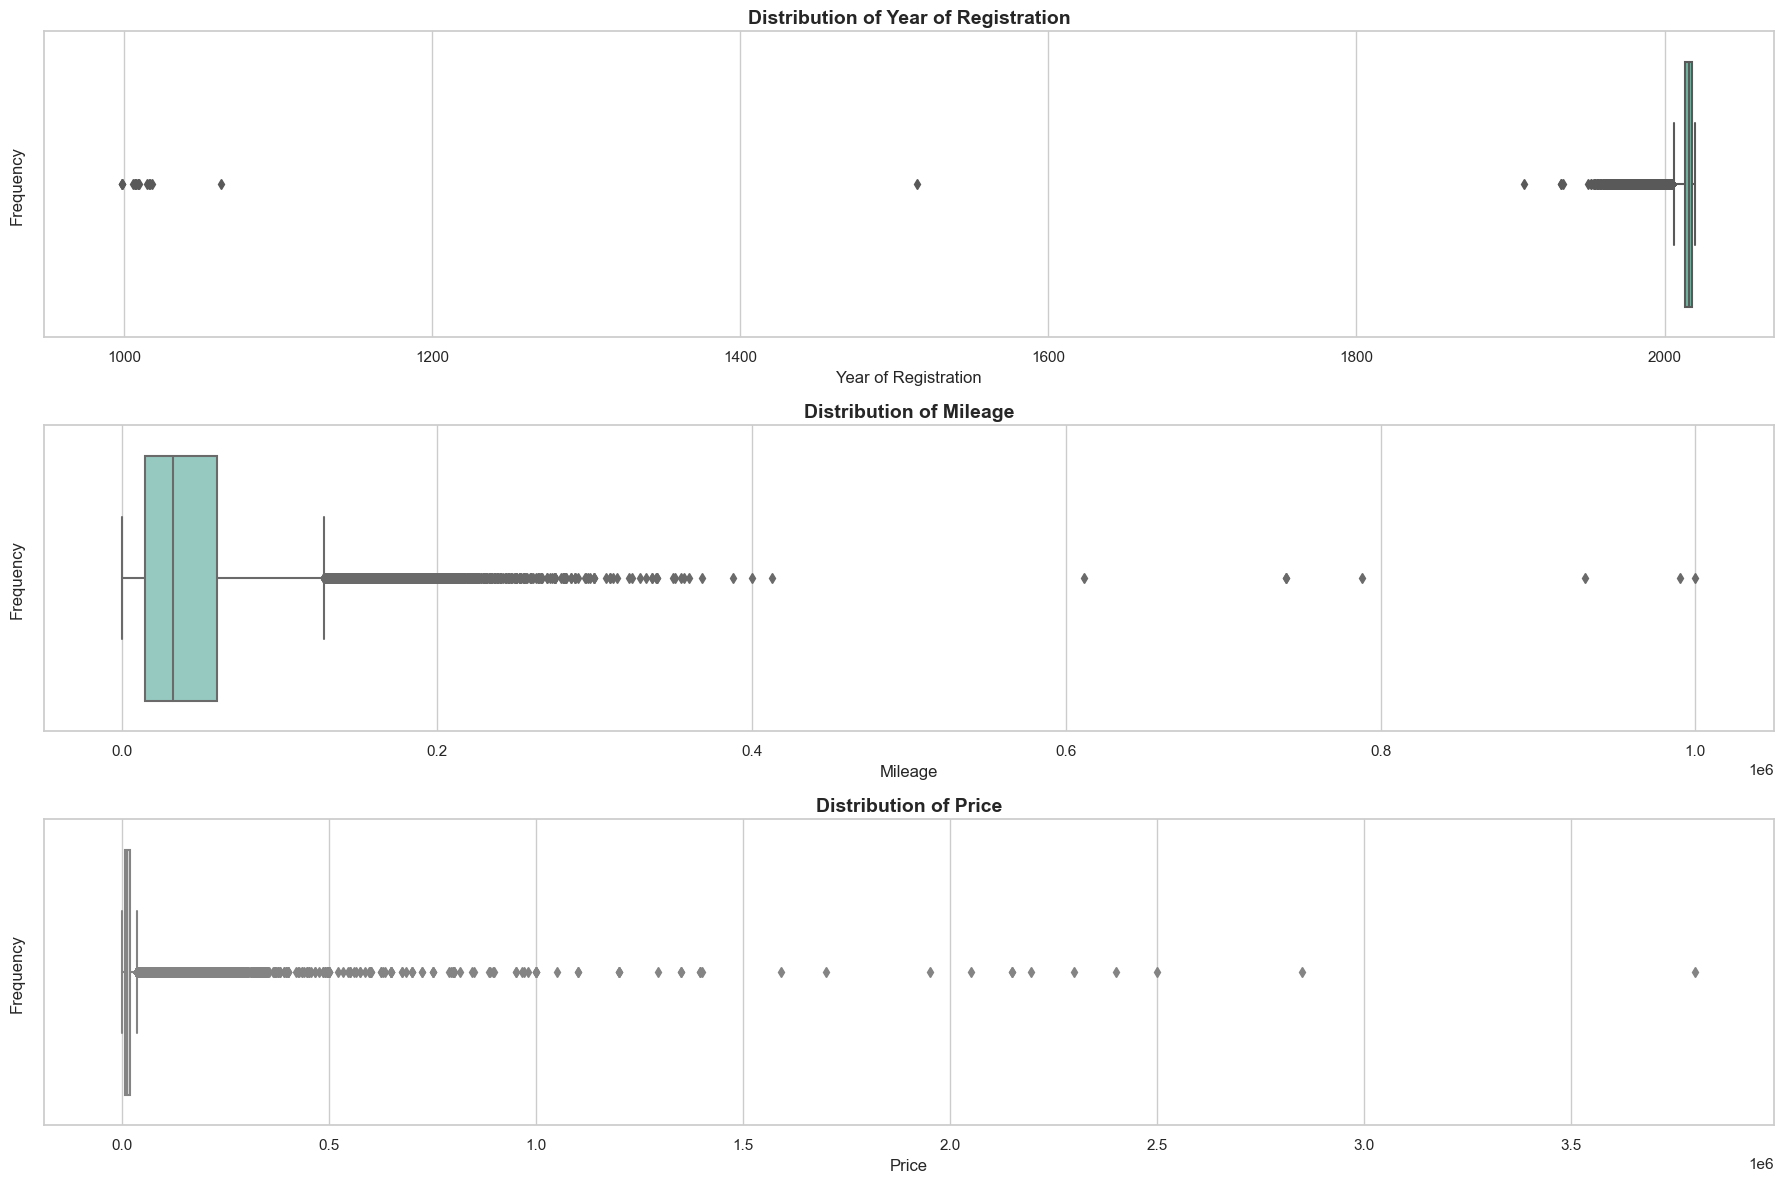

In [77]:
# Set the overall style and context
sns.set_theme(style="whitegrid", context="notebook")

# Create the figure with improved size
plt.figure(figsize=(18, 12))

# Boxplot for year_of_registration
plt.subplot(3, 1, 1)
sns.boxplot(x=car_df['year_of_registration'], palette="Set2")
plt.title("Distribution of Year of Registration", fontsize=14, fontweight="bold")
plt.xlabel("Year of Registration", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Boxplot for mileage
plt.subplot(3, 1, 2)
sns.boxplot(x=car_df['mileage'], palette="Set3")
plt.title("Distribution of Mileage", fontsize=14, fontweight="bold")
plt.xlabel("Mileage", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Boxplot for price
plt.subplot(3, 1, 3)
sns.boxplot(x=car_df['price'], palette="coolwarm")
plt.title("Distribution of Price", fontsize=14, fontweight="bold")
plt.xlabel("Price", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

In [78]:
# filter year_of_registration
car_df[car_df['year_of_registration'] < 1904]

,mileage,standard_colour,standard_make,standard_model,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
59010,14000.0,Blue,Toyota,Prius,1007.0,7000,Hatchback,False,Petrol Hybrid
69516,96659.0,Black,Audi,A4 Avant,1515.0,10385,Estate,False,Diesel
84501,37771.0,Black,Smart,fortwo,1063.0,4785,Coupe,False,Petrol
114737,30000.0,Red,Toyota,AYGO,1009.0,4695,Hatchback,False,Petrol
120858,27200.0,Black,MINI,Clubman,1016.0,18990,Estate,False,Diesel
190556,58470.0,Black,Fiat,Punto Evo,1010.0,3785,Hatchback,False,Petrol
199830,23000.0,Silver,MINI,Hatch,1009.0,5995,Hatchback,False,Petrol
199987,104000.0,Silver,BMW,1 Series,1008.0,4395,Convertible,False,Petrol
201616,8600.0,Silver,BMW,M2,1018.0,41990,Coupe,False,Petrol
201626,69346.0,Red,Mazda,Mazda3,999.0,8795,Saloon,False,Petrol


In [79]:
df[df['year_of_registration'] < 1904] # these are the rows where year_of_registration is less than 1904

,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
59010,202006270588110,14000.0,07,Blue,Toyota,Prius,USED,1007.0,7000,Hatchback,False,Petrol Hybrid
69516,202010155035879,96659.0,65,Black,Audi,A4 Avant,USED,1515.0,10385,Estate,False,Diesel
84501,202009163810376,37771.0,63,Black,Smart,fortwo,USED,1063.0,4785,Coupe,False,Petrol
114737,202008102305925,30000.0,59,Red,Toyota,AYGO,USED,1009.0,4695,Hatchback,False,Petrol
120858,202010064654489,27200.0,66,Black,MINI,Clubman,USED,1016.0,18990,Estate,False,Diesel
190556,202010205206488,58470.0,10,Black,Fiat,Punto Evo,USED,1010.0,3785,Hatchback,False,Petrol
199830,202009013167637,23000.0,59,Silver,MINI,Hatch,USED,1009.0,5995,Hatchback,False,Petrol
199987,202010225311657,104000.0,08,Silver,BMW,1 Series,USED,1008.0,4395,Convertible,False,Petrol
201616,202010134937656,8600.0,68,Silver,BMW,M2,USED,1018.0,41990,Coupe,False,Petrol
201626,202010155037484,69346.0,64,Red,Mazda,Mazda3,USED,999.0,8795,Saloon,False,Petrol


In [80]:
# filtering the year_of_registration and reg_code
df_filtered = df[df['year_of_registration'] < 1904]
df_filtered[['year_of_registration', 'reg_code']]

,year_of_registration,reg_code
59010,1007.0,07
69516,1515.0,65
84501,1063.0,63
114737,1009.0,59
120858,1016.0,66
190556,1010.0,10
199830,1009.0,59
199987,1008.0,08
201616,1018.0,68
201626,999.0,64


In [81]:
# lets remove duplicate combination and take all uniques:
unique_combinations = df_filtered[['year_of_registration', 
                                   'reg_code']].drop_duplicates().sort_values(by='year_of_registration', ascending=True)
unique_combinations

,year_of_registration,reg_code
201626,999.0,64
213059,999.0,08
334679,999.0,13
374798,1006.0,55
59010,1007.0,07
201773,1007.0,57
199987,1008.0,08
114737,1009.0,59
190556,1010.0,10
387633,1015.0,65


In [82]:
# creating a mapping dictionary: 
fix_error_year_dictionary = {
    999.0:  2014.0,    #64 
    999.0:  2008.0,    #08
    999.0:  2013.0,    #13
    1006.0: 2005.0,    #55
    1007.0: 2007.0,    #07
    1007.0: 2007.0,    #57
    1008.0: 2008.0,    #08
    1009.0: 2009.0,    #59
    1010.0: 2010.0,    #10
    1015.0: 2015.0,    #65
    1016.0: 2016.0,    #66
    1017.0: 2017.0,    #17
    1018.0: 2018.0,    #68
    1063.0: 2013.0,    #63
    1515.0: 2015.0,    #65
    
}

fix_error_year_dictionary   # print dictionary

{999.0: 2013.0,
 1006.0: 2005.0,
 1007.0: 2007.0,
 1008.0: 2008.0,
 1009.0: 2009.0,
 1010.0: 2010.0,
 1015.0: 2015.0,
 1016.0: 2016.0,
 1017.0: 2017.0,
 1018.0: 2018.0,
 1063.0: 2013.0,
 1515.0: 2015.0}

In [83]:
# fix the error in the year of registration column that has years less than 1904
# Replace the values in the year of registration column using the mapping dictionary
car_df['year_of_registration'].replace(fix_error_year_dictionary, inplace=True)

In [84]:
# Lets check now if year of registration is fixed
car_df.loc[car_df['year_of_registration'] < 1904]

,mileage,standard_colour,standard_make,standard_model,year_of_registration,price,body_type,crossover_car_and_van,fuel_type


- Success

#### **Interquartile Range (IQR) method**:

In [85]:
# Lets check shape of dataframe before IQR
car_df.shape

(370426, 9)

In [86]:
# Optimized Code for IQR:

# Step 1: Compute IQR for numeric columns
numeric_cols = car_df.select_dtypes(include=[np.number]).columns
Q1 = car_df[numeric_cols].quantile(0.25)  # First quartile (25th percentile)
Q3 = car_df[numeric_cols].quantile(0.75)  # Third quartile (75th percentile)
IQR = Q3 - Q1  

# Step 2: Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Step 3: Filter dataset to exclude rows with outliers
car_df_cleaned = car_df[
    ~((car_df[numeric_cols] < lower_bound) | (car_df[numeric_cols] > upper_bound)).any(axis=1)
]

# Step 4: Display the cleaned dataset shape
print(f"Original dataset shape: {car_df.shape}")
print(f"Cleaned dataset shape: {car_df_cleaned.shape}")

Original dataset shape: (370426, 9)
Cleaned dataset shape: (332098, 9)


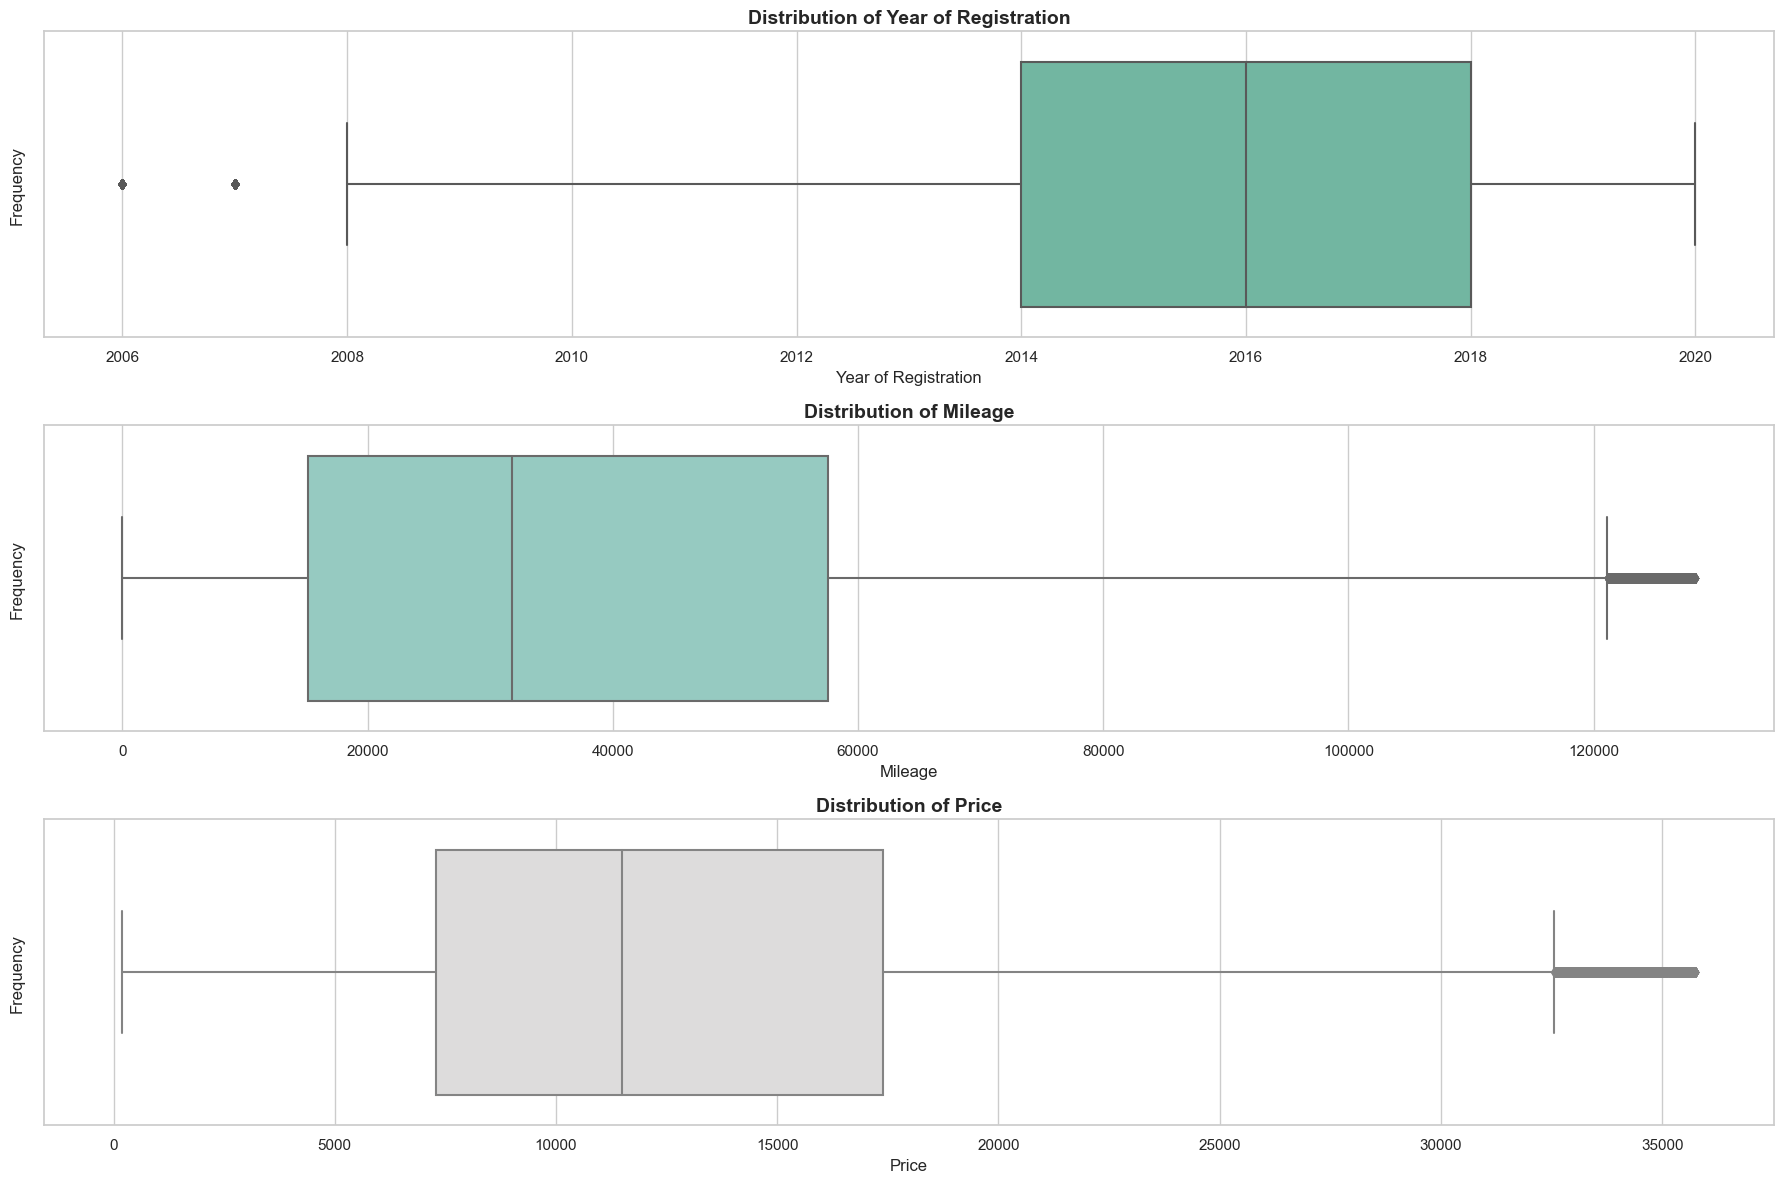

In [87]:
# Set the overall style and context
sns.set_theme(style="whitegrid", context="notebook")

# Create the figure with improved size
plt.figure(figsize=(18, 12))

# Boxplot for year_of_registration
plt.subplot(3, 1, 1)
sns.boxplot(x=car_df_cleaned['year_of_registration'], palette="Set2")
plt.title("Distribution of Year of Registration", fontsize=14, fontweight="bold")
plt.xlabel("Year of Registration", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Boxplot for mileage
plt.subplot(3, 1, 2)
sns.boxplot(x=car_df_cleaned['mileage'], palette="Set3")
plt.title("Distribution of Mileage", fontsize=14, fontweight="bold")
plt.xlabel("Mileage", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Boxplot for price
plt.subplot(3, 1, 3)
sns.boxplot(x=car_df_cleaned['price'], palette="coolwarm")
plt.title("Distribution of Price", fontsize=14, fontweight="bold")
plt.xlabel("Price", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

In [88]:
car_df_cleaned.describe()

,mileage,year_of_registration,price
count,332098.000000,332098.000000,332098.000000
mean,38945.724913,2015.467720,12963.786503
std,29738.350521,3.320114,7520.981315
min,0.000000,2006.000000,200.000000
25%,15129.250000,2014.000000,7295.000000
50%,31758.000000,2016.000000,11500.000000
75%,57525.750000,2018.000000,17399.000000
max,128300.000000,2020.000000,35750.000000


In [89]:
# checking each columns to see if now the outliers have been handled:

# Price
car_df_cleaned.sort_values('price', ascending=False).head(3)  

,mileage,standard_colour,standard_make,standard_model,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
18468,39000.0,White,Land Rover,Range Rover Sport,2016.0,35750,SUV,False,Diesel
299075,12700.0,Black,BMW,M2,2018.0,35750,Coupe,False,Petrol
286460,3971.0,Blue,Mercedes-Benz,GLC Class,2020.0,35750,SUV,False,Diesel


In [90]:
# year_of_registration
car_df_cleaned.sort_values('year_of_registration', ascending=False).head(3)

,mileage,standard_colour,standard_make,standard_model,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
340623,4999.0,Grey,SEAT,Arona,2020.0,18950,SUV,False,Petrol
353275,4756.0,Blue,BMW,2 Series Active Tourer,2020.0,20490,MPV,False,Petrol
43305,3599.0,Black,Audi,A4,2020.0,34999,Saloon,False,Diesel


In [91]:
# mileage
car_df_cleaned.sort_values('mileage', ascending=False).head(3)

,mileage,standard_colour,standard_make,standard_model,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
240780,128300.0,Silver,Saab,9-3,2007.0,1595,Saloon,False,Diesel
278158,128300.0,Grey,Audi,A4,2007.0,2300,Saloon,False,Diesel
196349,128300.0,Black,Audi,A5 Cabriolet,2011.0,6620,Convertible,False,Diesel


- we have successfully cleaned our dataframe and also handled the outliers. Now our data is ready for further steps.

## Data Manipulation (car_df_cleaned)

#### Step1: calculate age of vehicle based on current date and year of registration:

In [92]:
# converting to integrer
car_df_cleaned['year_of_registration'] = car_df_cleaned['year_of_registration'].astype('int64')

In [93]:
# Lets get current year from datetime module
import datetime

current_year = datetime.datetime.now().year
current_year

2025

In [94]:
# creating a new column 'age_of_vehicle' in dataset
car_df_cleaned = car_df_cleaned.assign(age_of_vehicle =  current_year - car_df['year_of_registration'])
car_df_cleaned['age_of_vehicle'] = car_df_cleaned['age_of_vehicle'].astype('int64')
car_df_cleaned.head()

,mileage,standard_colour,standard_make,standard_model,year_of_registration,price,body_type,crossover_car_and_van,fuel_type,age_of_vehicle
1,108230.0,Blue,Jaguar,XF,2011,7000,Saloon,False,Diesel,14
2,7800.0,Grey,SKODA,Yeti,2017,14000,SUV,False,Petrol,8
3,45000.0,Brown,Vauxhall,Mokka,2016,7995,Hatchback,False,Diesel,9
4,64000.0,Grey,Land Rover,Range Rover Sport,2015,26995,SUV,False,Diesel,10
5,16000.0,Blue,Audi,S5,2017,29000,Convertible,False,Petrol,8


#### Step2: creating a categorical column from year of registration feature

In [95]:
# lets check the max and min of year of registration to understand and build a logical outcome here
car_df_cleaned['year_of_registration'].min(), car_df_cleaned['year_of_registration'].max()

(2006, 2020)

In [96]:
# lets explore stats here
car_df_cleaned.year_of_registration.describe()

count    332098.000000
mean       2015.467720
std           3.320114
min        2006.000000
25%        2014.000000
50%        2016.000000
75%        2018.000000
max        2020.000000
Name: year_of_registration, dtype: float64

In [97]:
# create a new column 'condition_of_vehicle' using bins 
car_df_cleaned['condition_of_vehicle'] = pd.cut(car_df_cleaned['year_of_registration'],    
                                                bins=[2006, 2013, 2017, 2020], 
                                                labels=['OLD', 'MID-AGE', 'NEW']
                                               )
car_df_cleaned['condition_of_vehicle'] = car_df_cleaned['condition_of_vehicle'].astype('object')
car_df_cleaned.head()

,mileage,standard_colour,standard_make,standard_model,year_of_registration,price,body_type,crossover_car_and_van,fuel_type,age_of_vehicle,condition_of_vehicle
1,108230.0,Blue,Jaguar,XF,2011,7000,Saloon,False,Diesel,14,OLD
2,7800.0,Grey,SKODA,Yeti,2017,14000,SUV,False,Petrol,8,MID-AGE
3,45000.0,Brown,Vauxhall,Mokka,2016,7995,Hatchback,False,Diesel,9,MID-AGE
4,64000.0,Grey,Land Rover,Range Rover Sport,2015,26995,SUV,False,Diesel,10,MID-AGE
5,16000.0,Blue,Audi,S5,2017,29000,Convertible,False,Petrol,8,MID-AGE


#### Step3: creating a categorical column from mileage feature

In [98]:
# lets check the max and min of mileage to understand and build a logical outcome here
car_df_cleaned['mileage'].min(), car_df_cleaned['mileage'].max()

(0.0, 128300.0)

In [99]:
# lets explore stats here
car_df_cleaned.mileage.describe()

count    332098.000000
mean      38945.724913
std       29738.350521
min           0.000000
25%       15129.250000
50%       31758.000000
75%       57525.750000
max      128300.000000
Name: mileage, dtype: float64

In [100]:
# Create a new column 'usage_of_vehicle'
car_df_cleaned['usage_of_vehicle'] = pd.cut(car_df_cleaned['mileage'],
                                     bins=[0.0, 15129.0, 57525.0, 128300.0],
                                     labels=['LOW','AVERAGE','HIGH'],
                                     right=False,
                                     include_lowest=True
                                     )
car_df_cleaned['usage_of_vehicle'] = car_df_cleaned['usage_of_vehicle'].astype('object')

car_df_cleaned.head()

,mileage,standard_colour,standard_make,standard_model,year_of_registration,price,body_type,crossover_car_and_van,fuel_type,age_of_vehicle,condition_of_vehicle,usage_of_vehicle
1,108230.0,Blue,Jaguar,XF,2011,7000,Saloon,False,Diesel,14,OLD,HIGH
2,7800.0,Grey,SKODA,Yeti,2017,14000,SUV,False,Petrol,8,MID-AGE,LOW
3,45000.0,Brown,Vauxhall,Mokka,2016,7995,Hatchback,False,Diesel,9,MID-AGE,AVERAGE
4,64000.0,Grey,Land Rover,Range Rover Sport,2015,26995,SUV,False,Diesel,10,MID-AGE,HIGH
5,16000.0,Blue,Audi,S5,2017,29000,Convertible,False,Petrol,8,MID-AGE,AVERAGE


In [101]:
car_df_cleaned.dtypes

mileage                  float64
standard_colour           object
standard_make             object
standard_model            object
year_of_registration       int64
price                      int64
body_type                 object
crossover_car_and_van       bool
fuel_type                 object
age_of_vehicle             int64
condition_of_vehicle      object
usage_of_vehicle          object
dtype: object

## EDA - Exploratory Data Analysis on Curated Dataframe

1. **Range of Years**

Range of years: 2006 to 2020


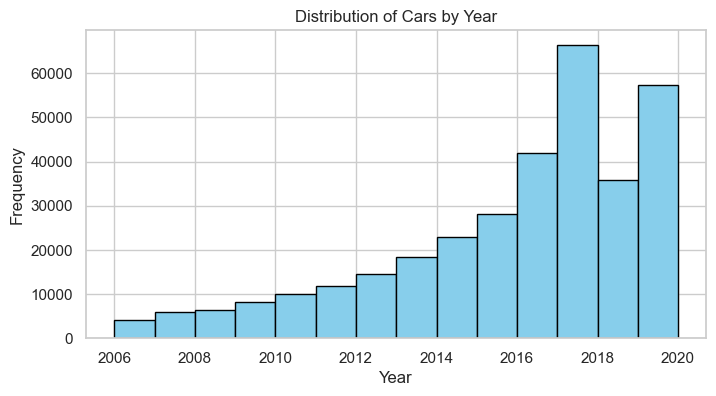

In [102]:
min_year = car_df_cleaned['year_of_registration'].min()
max_year = car_df_cleaned['year_of_registration'].max()
print(f"Range of years: {min_year} to {max_year}")
plt.figure(figsize=(8, 4))
plt.hist(car_df_cleaned['year_of_registration'], 
         bins=range( car_df_cleaned['year_of_registration'].min(), car_df_cleaned['year_of_registration'].max() + 1), 
         color='skyblue', edgecolor='black')
plt.title('Distribution of Cars by Year')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

2. **Max vs. Min Selling Prices**

Maximum selling price: 35750
Minimum selling price: 200
Car with Maximum Selling Price of  BMW  is in 35750
Car with Minimum Selling Priceof  Renault  is in 200


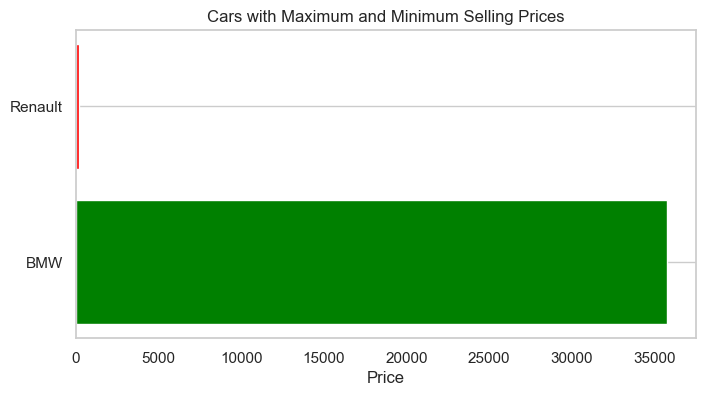

In [103]:
max_selling_car = car_df_cleaned.loc[car_df_cleaned['price'].idxmax(), 'standard_make']
min_selling_car = car_df_cleaned.loc[car_df_cleaned['price'].idxmin(), 'standard_make']
max_selling_price = car_df_cleaned['price'].max()
min_selling_price = car_df_cleaned['price'].min()
print("Maximum selling price:", max_selling_price)
print("Minimum selling price:", min_selling_price)
print("Car with Maximum Selling Price of ", max_selling_car," is in",max_selling_price)
print("Car with Minimum Selling Priceof ", min_selling_car," is in",min_selling_price)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh([max_selling_car, min_selling_car], [car_df_cleaned['price'].max(), car_df_cleaned['price'].min()], color=['green', 'red'])
plt.xlabel('Price')
plt.title('Cars with Maximum and Minimum Selling Prices')
plt.grid(axis='x')
plt.show()

3. **Fuel type**

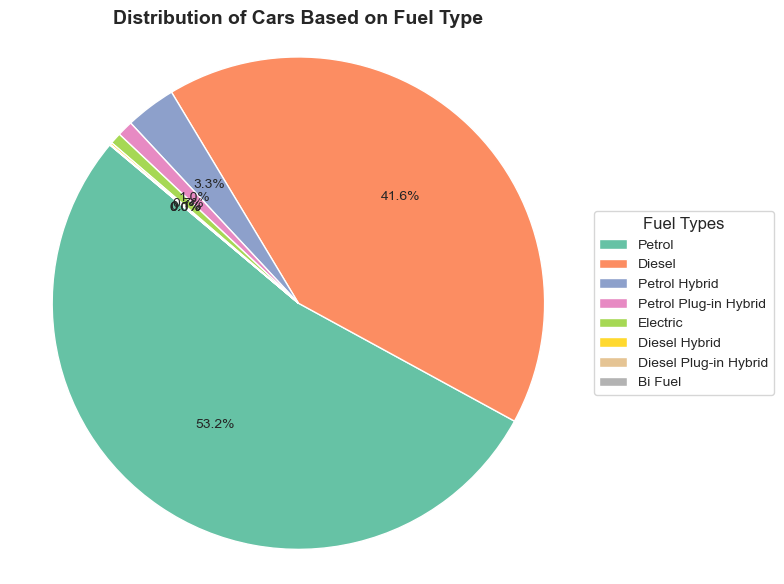

In [104]:
fuel_type_counts = car_df_cleaned['fuel_type'].value_counts()

# Define colors for the pie chart
colors = plt.cm.Set2.colors  # Use a colormap for distinct colors

# Create the pie chart without labels
plt.figure(figsize=(8, 6))
plt.pie(
    fuel_type_counts,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    textprops={'fontsize': 10}
)

# Add a legend to the side
plt.legend(
    labels=fuel_type_counts.index,  # Use the fuel type names as labels
    title="Fuel Types",
    loc="center left",  # Position the legend to the left or adjust as needed
    bbox_to_anchor=(1, 0.5),  # Position it outside the pie chart
    fontsize=10
)

# Add a title
plt.title('Distribution of Cars Based on Fuel Type', fontsize=14, fontweight='bold')
plt.axis('equal')  # Ensure the pie chart remains a circle
plt.tight_layout()
plt.show()


4. **Body Type**

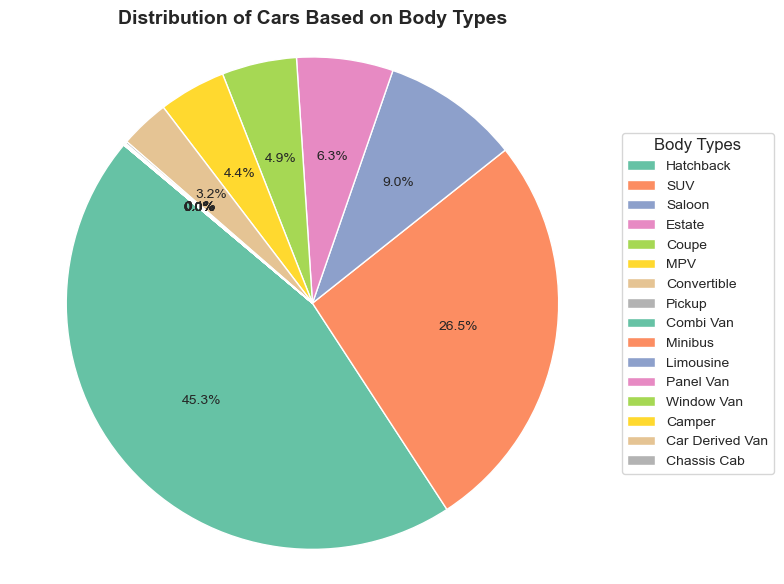

In [105]:
body_type_counts = car_df_cleaned['body_type'].value_counts()

# Define colors for the pie chart
colors = plt.cm.Set2.colors  # Use a colormap for distinct colors

# Create the pie chart without labels
plt.figure(figsize=(8, 6))
plt.pie(
    body_type_counts,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    textprops={'fontsize': 10}
)

# Add a legend to the side
plt.legend(
    labels=body_type_counts.index,  # Use the body type names as labels
    title="Body Types",
    loc="center left",  # Position the legend to the left or adjust as needed
    bbox_to_anchor=(1, 0.5),  # Position it outside the pie chart
    fontsize=10
)

# Add a title
plt.title('Distribution of Cars Based on Body Types', fontsize=14, fontweight='bold')
plt.axis('equal')  # Ensure the pie chart remains a circle
plt.tight_layout()
plt.show()


- **Lets find Correlation between the price and other features.**

In [106]:
car_df_cleaned.columns

Index(['mileage', 'standard_colour', 'standard_make', 'standard_model',
       'year_of_registration', 'price', 'body_type', 'crossover_car_and_van',
       'fuel_type', 'age_of_vehicle', 'condition_of_vehicle',
       'usage_of_vehicle'],
      dtype='object')

In [107]:
# selecting few required numeric and boolean columns
num_cols = ['price', 'year_of_registration', 'mileage', 'age_of_vehicle', 'crossover_car_and_van']
num_car_df = car_df_cleaned[num_cols]

# correlation matrix
corr_matrix =num_car_df.corr()
corr_matrix

,price,year_of_registration,mileage,age_of_vehicle,crossover_car_and_van
price,1.000000,0.614537,-0.510568,-0.614537,0.048208
year_of_registration,0.614537,1.000000,-0.755900,-1.000000,-0.003766
mileage,-0.510568,-0.755900,1.000000,0.755900,0.020383
age_of_vehicle,-0.614537,-1.000000,0.755900,1.000000,0.003766
crossover_car_and_van,0.048208,-0.003766,0.020383,0.003766,1.000000


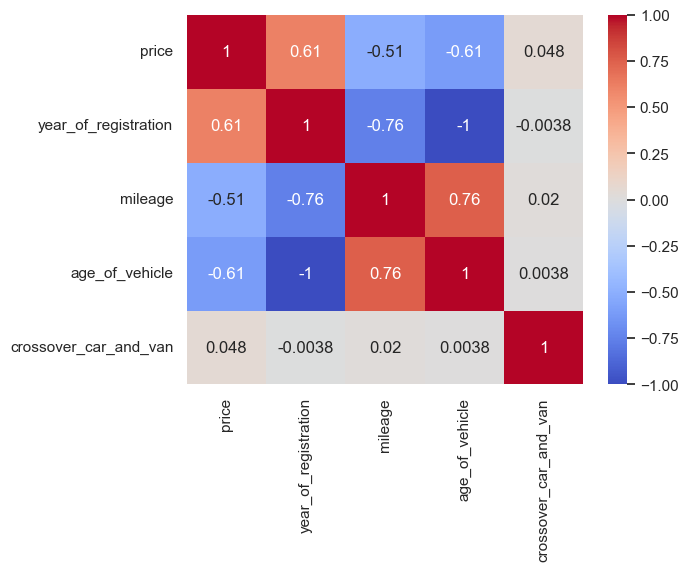

In [108]:
# Plotting a heatmap for the same
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

### Lets see what features affect the price of vehicle and How to better understand the result we will be forming while doing ML-Predictions:

#### Average Price of vehicles based on body type

In [113]:
# lets get value counts of each body type:
car_df_cleaned.body_type.value_counts()

Hatchback          150465
SUV                 87954
Saloon              29962
Estate              21036
Coupe               16315
MPV                 14641
Convertible         10787
Pickup                444
Combi Van             190
Minibus               131
Limousine              62
Panel Van              40
Window Van             40
Camper                 29
Car Derived Van         1
Chassis Cab             1
Name: body_type, dtype: int64

In [114]:
# Lets perform groupby on bodytype to calculate average price accordingly for each body type
body_type_vs_price = car_df_cleaned.groupby('body_type')["price"].mean().sort_values(ascending=False)
body_type_vs_price

body_type
Camper             23460.241379
Minibus            20319.664122
Chassis Cab        19750.000000
Pickup             17450.540541
SUV                16590.973839
Saloon             16313.044456
Combi Van          15992.263158
Coupe              15645.248667
Estate             14262.322305
Convertible        13996.499954
Limousine          13117.758065
Panel Van          13038.950000
Window Van         11276.050000
MPV                10759.241855
Car Derived Van    10495.000000
Hatchback           9819.612076
Name: price, dtype: float64

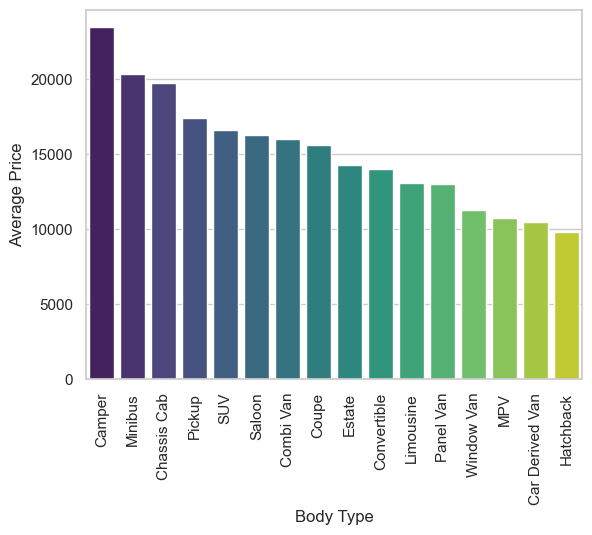

In [115]:
# Lets plot the above result.
sns.barplot(x=body_type_vs_price.index, y=body_type_vs_price.values, palette="viridis")
plt.xlabel("Body Type")  # x-axis title
plt.ylabel("Average Price") # y-axis title
plt.xticks(rotation=90) # rotate x-axis label by 45degrees
plt.show() # plot

#### Average Price of vehicles based on Fuel type

In [116]:
# lets get value counts of each fuel type:
car_df_cleaned.fuel_type.value_counts()

Petrol                   176536
Diesel                   138055
Petrol Hybrid             11013
Petrol Plug-in Hybrid      3429
Electric                   2456
Diesel Hybrid               463
Diesel Plug-in Hybrid        89
Bi Fuel                      57
Name: fuel_type, dtype: int64

In [117]:
# Lets perform groupby on fueltype to calculate average price accordingly for each fuel type
fuel_type_vs_price = car_df_cleaned.groupby('fuel_type')["price"].mean().sort_values(ascending=False)
fuel_type_vs_price

fuel_type
Diesel Plug-in Hybrid    28312.348315
Diesel Hybrid            23588.609071
Petrol Plug-in Hybrid    21655.775736
Electric                 19119.593241
Petrol Hybrid            17126.527104
Diesel                   14122.152657
Bi Fuel                  12511.982456
Petrol                   11508.301185
Name: price, dtype: float64

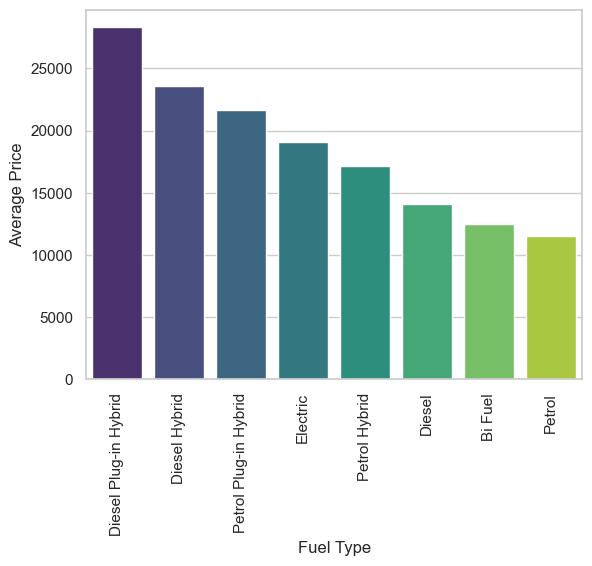

In [118]:
# Lets plot the above result.
sns.barplot(x=fuel_type_vs_price.index, y=fuel_type_vs_price.values, palette="viridis")
plt.xlabel("Fuel Type")  # x-axis title
plt.ylabel("Average Price") # y-axis title
plt.xticks(rotation=90) # rotate x-axis label by 45degrees
plt.show() # plot

#### Average Price of vehicles based on year of registeration

In [119]:
# Lets perform groupby on year of registration to calculate average price accordingly for each registration year
year_vs_price = car_df_cleaned.groupby('year_of_registration')["price"].mean().sort_values(ascending=False)
year_vs_price

year_of_registration
2020    22319.374939
2019    19200.966670
2018    15683.148515
2017    14385.124400
2016    13259.935511
2015    11572.650595
2014    10075.748987
2013     8561.288489
2012     7251.804122
2011     6310.884863
2010     5368.278343
2009     4730.115184
2007     4437.525479
2006     4418.421404
2008     4395.070543
Name: price, dtype: float64

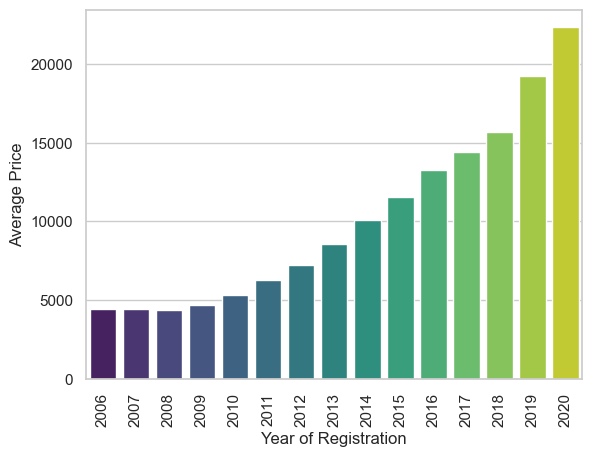

In [120]:
# Lets plot the above result.
sns.barplot(x=year_vs_price.index, y=year_vs_price.values, palette="viridis")
plt.xlabel("Year of Registration")  # x-axis title
plt.ylabel("Average Price") # y-axis title
plt.xticks(rotation=90) # rotate x-axis label by 45degrees
plt.show() # plot

**Price Trends by Year**

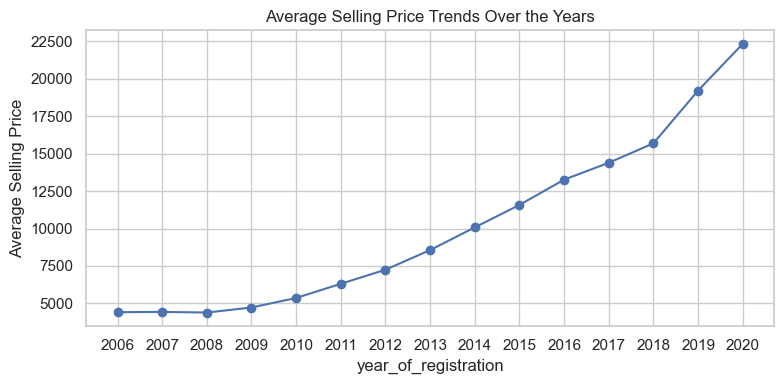

In [121]:
price_trends = car_df_cleaned.groupby('year_of_registration')['price'].mean().reset_index()

# Sorting the DataFrame by year
price_trends = price_trends.sort_values(by='year_of_registration')

# Plotting the price trends
plt.figure(figsize=(8, 4))
plt.plot(price_trends['year_of_registration'], price_trends['price'], marker='o', linestyle='-')
plt.title('Average Selling Price Trends Over the Years')
plt.xlabel('year_of_registration')
plt.ylabel('Average Selling Price')
plt.grid(True)
plt.xticks(price_trends['year_of_registration'])
plt.tight_layout()
plt.show()

#### Average Price of vehicles based on Mileage

In [122]:
car_df_cleaned.sort_values('mileage', ascending=True).head(2)    # lowest mileage - Price

,mileage,standard_colour,standard_make,standard_model,year_of_registration,price,body_type,crossover_car_and_van,fuel_type,age_of_vehicle,condition_of_vehicle,usage_of_vehicle
263323,0.0,Red,Honda,Jazz,2020,21000,Hatchback,False,Petrol Hybrid,5,NEW,LOW
129598,0.0,Red,Volkswagen,Polo,2020,15499,Hatchback,False,Petrol,5,NEW,LOW


In [123]:
car_df_cleaned.sort_values('mileage', ascending=False).head(3)   # highest mileage - Price

,mileage,standard_colour,standard_make,standard_model,year_of_registration,price,body_type,crossover_car_and_van,fuel_type,age_of_vehicle,condition_of_vehicle,usage_of_vehicle
240780,128300.0,Silver,Saab,9-3,2007,1595,Saloon,False,Diesel,18,OLD,NaN
278158,128300.0,Grey,Audi,A4,2007,2300,Saloon,False,Diesel,18,OLD,NaN
196349,128300.0,Black,Audi,A5 Cabriolet,2011,6620,Convertible,False,Diesel,14,OLD,NaN


In [124]:
# lets check stats
car_df_cleaned.mileage.describe()

count    332098.000000
mean      38945.724913
std       29738.350521
min           0.000000
25%       15129.250000
50%       31758.000000
75%       57525.750000
max      128300.000000
Name: mileage, dtype: float64

In [125]:
# Group the data by 10,000 mile intervals to calculate the mean price for each interval and see result
mileage_vs_price = car_df_cleaned.groupby(pd.cut(car_df_cleaned['mileage'], 
                                                bins=range(0, 140000, 10000)))['price'].mean().reset_index()
mileage_vs_price

,mileage,price
0,"(0, 10000]",19502.869589
1,"(10000, 20000]",15125.777331
2,"(20000, 30000]",13912.167644
3,"(30000, 40000]",12820.314368
4,"(40000, 50000]",11569.046545
5,"(50000, 60000]",10396.598906
6,"(60000, 70000]",9217.724765
7,"(70000, 80000]",8223.043839
8,"(80000, 90000]",7275.925984
9,"(90000, 100000]",6510.413818


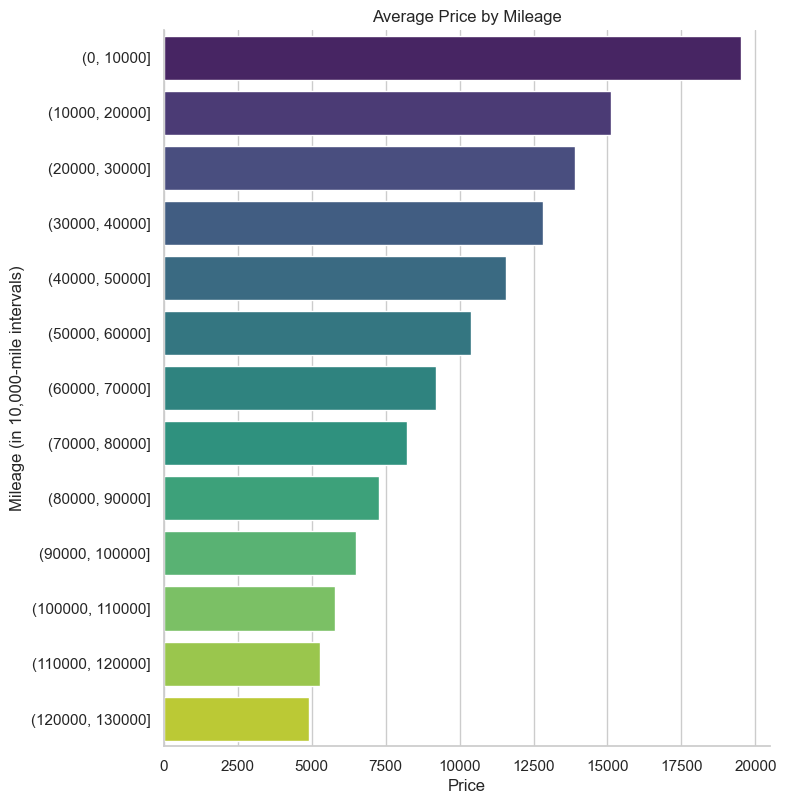

In [126]:
sns.catplot(data=mileage_vs_price, x='price', y="mileage",kind="bar", height=8, palette="viridis")
# Set the plot title and axis labels
plt.title('Average Price by Mileage')
plt.xlabel('Price')
plt.ylabel('Mileage (in 10,000-mile intervals)')
# Show the plot
plt.show()

## we save our cleaned dataset here as csv (locally) inorder to utilize for machine learning purpose - model training

In [129]:
# we save and reload this cleaned_data for model repeated training and testing
car_df_cleaned.to_csv("car_df_cleaned.csv", index=False)

## Data Pre-Processing and Transformation for Model training

In [130]:
import pandas as pd
import numpy as np
import pickle
import time
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import LinearSVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import warnings
warnings.filterwarnings("ignore")

In [131]:
# Convert sample data to DataFrame
car_df = pd.read_csv('car_df_cleaned.csv')

In [132]:
car_df.head(3)

,mileage,standard_colour,standard_make,standard_model,year_of_registration,price,body_type,crossover_car_and_van,fuel_type,age_of_vehicle,condition_of_vehicle,usage_of_vehicle
0,108230.0,Blue,Jaguar,XF,2011,7000,Saloon,False,Diesel,14,OLD,HIGH
1,7800.0,Grey,SKODA,Yeti,2017,14000,SUV,False,Petrol,8,MID-AGE,LOW
2,45000.0,Brown,Vauxhall,Mokka,2016,7995,Hatchback,False,Diesel,9,MID-AGE,AVERAGE


#### LabelEncoder for transforming Categorical Data

In [133]:
# Encoding categorical columns using LabelEncoder
label_encoders = {}

categorical_columns = ['standard_colour', 'standard_make', 'standard_model', 'body_type', 
                       'fuel_type', 'condition_of_vehicle', 'usage_of_vehicle']

for col in categorical_columns:
    le = LabelEncoder()
    car_df[col] = le.fit_transform(car_df[col])
    label_encoders[col] = le  # Store label encoder for potential future use

In [134]:
# Define input and output data (X and Y):
input_data = car_df[["mileage", "standard_colour", "standard_make", "standard_model", "year_of_registration", 
                             "body_type", "crossover_car_and_van", "fuel_type", "age_of_vehicle", "condition_of_vehicle", 
                             "usage_of_vehicle"]]
output_data = car_df["price"]

#### Standardize Numerical Data using StandardScaler

In [135]:
# Standardize the input data
ss = StandardScaler()
input_data = pd.DataFrame(ss.fit_transform(input_data), columns=input_data.columns)

input_data.head(5)

,mileage,standard_colour,standard_make,standard_model,year_of_registration,body_type,crossover_car_and_van,fuel_type,age_of_vehicle,condition_of_vehicle,usage_of_vehicle
0,2.329799,-1.037939,-0.457240,1.698092,-1.345655,1.524517,-0.058379,-1.171532,1.345655,1.464407,0.301467
1,-1.047327,-0.273509,0.805764,1.741568,0.461515,1.216141,-0.058379,0.799071,-0.461515,-0.919413,1.507457
2,0.203585,-0.783129,1.184665,0.519897,0.160320,-0.634114,-0.058379,-1.171532,-0.160320,-0.919413,-0.904524
3,0.842492,-0.273509,-0.330940,0.928570,-0.140875,1.216141,-0.058379,-1.171532,0.140875,-0.919413,0.301467
4,-0.771588,-1.037939,-1.551844,1.037260,0.461515,-1.559242,-0.058379,0.799071,-0.461515,-0.919413,-0.904524


#### Saving our Label Encoder and Standard Scaler for Future use

In [136]:
# Define a dictionary to store the LabelEncoders and StandardScaler
preprocessing_objects = {
    "label_encoders": label_encoders,  # Dictionary of LabelEncoders
    "scaler": ss  # StandardScaler
}

# Save the preprocessing objects to a pickle file
with open("preprocessing_objects.pkl", "wb") as file:
    pickle.dump(preprocessing_objects, file)

print("Preprocessing objects saved successfully!")

Preprocessing objects saved successfully!


## Model Building and Training

#### Data Partition: Train and Test

In [137]:
# Split the dataset into training, validation, and test sets
x_train, x_temp, y_train, y_temp = train_test_split(input_data, output_data, test_size=0.2, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

print("Training set shape:", x_train.shape, y_train.shape)
print("Validation set shape:", x_val.shape, y_val.shape)
print("Testing set shape:", x_test.shape, y_test.shape)

Training set shape: (265678, 11) (265678,)
Validation set shape: (33210, 11) (33210,)
Testing set shape: (33210, 11) (33210,)


#### Model 1: Linear Regression 

Training Linear Regression...
Cross-validation for Linear Regression - RMSE: 28080315.40151464, R^2: 50.39354319510348
Linear Regression:
    Train RMSE: 5298.7947391519665, Validation RMSE: 5317.10783943165
    Train R^2: 50.40054139519472, Validation R^2: 49.73982589484392
    Train MAE: 4001.976654127086, Validation MAE: 4001.4982578986724
    Train MSE: 28077225.687664554, Validation MSE: 28271635.776145514


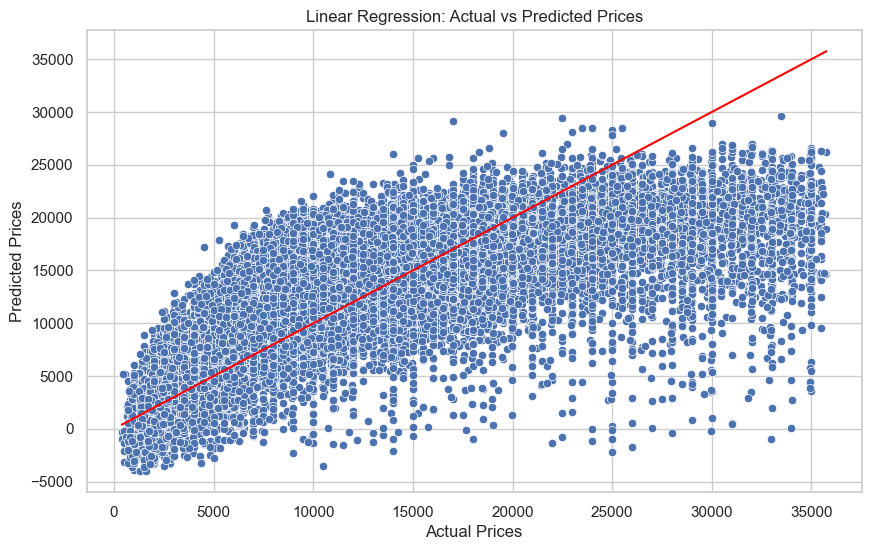

In [138]:
# Linear Regression Model
print("Training Linear Regression...")

# Model Training
lr = LinearRegression()
lr.fit(x_train, y_train)

# Cross-Validation
cv_score_best = cross_val_score(lr, x_train, y_train, cv=5, scoring='neg_mean_squared_error')
mean_cv_rmse_best = -cv_score_best.mean()
cv_r2_best = cross_val_score(lr, x_train, y_train, cv=5, scoring='r2').mean()
print(f"Cross-validation for Linear Regression - RMSE: {mean_cv_rmse_best}, R^2: {cv_r2_best*100}")

# Predicting on train and validation set
y_train_pred_lr = lr.predict(x_train)
y_val_pred_lr = lr.predict(x_val)

# Calculating metrics for Linear Regression
train_rmse_lr = mean_squared_error(y_train, y_train_pred_lr, squared=False)
val_rmse_lr = mean_squared_error(y_val, y_val_pred_lr, squared=False)
train_r2_lr = r2_score(y_train, y_train_pred_lr)
val_r2_lr = r2_score(y_val, y_val_pred_lr)
train_mae_lr = mean_absolute_error(y_train, y_train_pred_lr)
val_mae_lr = mean_absolute_error(y_val, y_val_pred_lr)
train_mse_lr = mean_squared_error(y_train, y_train_pred_lr)
val_mse_lr = mean_squared_error(y_val, y_val_pred_lr)

# Print results for Linear Regression
print(f"Linear Regression:\n"
      f"    Train RMSE: {train_rmse_lr}, Validation RMSE: {val_rmse_lr}\n"
      f"    Train R^2: {train_r2_lr*100}, Validation R^2: {val_r2_lr*100}\n"
      f"    Train MAE: {train_mae_lr}, Validation MAE: {val_mae_lr}\n"
      f"    Train MSE: {train_mse_lr}, Validation MSE: {val_mse_lr}")

# Plotting Actual vs Predicted
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_val, y=y_val_pred_lr)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], color='red')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Linear Regression: Actual vs Predicted Prices')
plt.show()


#### Model 2: Decision Tree Regressor

Training Decision Tree...
Cross-validation for Decision Tree - RMSE: 7174220.621925587, R^2: 87.32555578366103
Random Forest:
    Train RMSE: 284.82526710838056, Validation RMSE: 2643.0844610440004
    Train R^2: 99.85668891969968, Validation R^2: 87.58075672405828
    Train MAE: 39.60663054361109, Validation MAE: 1726.5101336483663
    Train MSE: 81125.43278336033, Validation MSE: 6985895.468212253


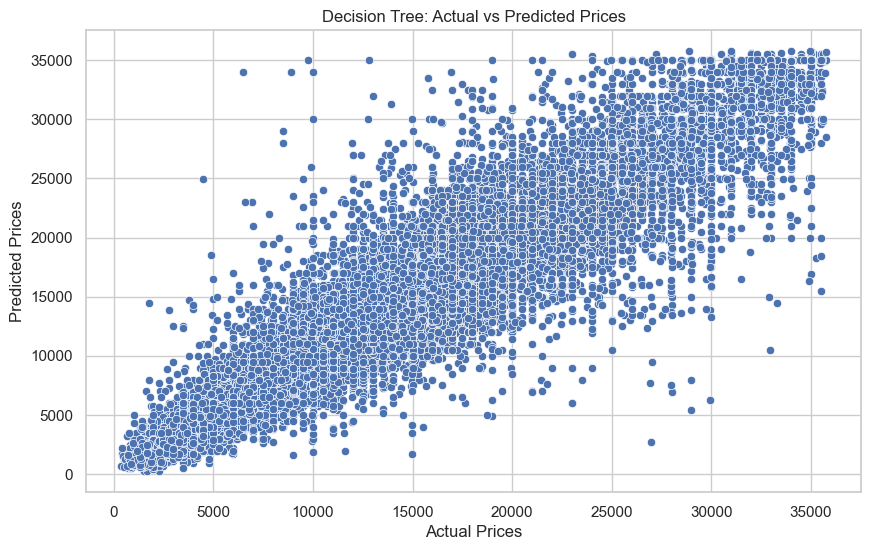

In [139]:
# Decision Tree Model
print("Training Decision Tree...")

# Model Training
dt = DecisionTreeRegressor(random_state=42)
dt.fit(x_train, y_train)

# Cross-Validation
cv_score_best = cross_val_score(dt, x_train, y_train, cv=5, scoring='neg_mean_squared_error')
mean_cv_rmse_best = -cv_score_best.mean()
cv_r2_best = cross_val_score(dt, x_train, y_train, cv=5, scoring='r2').mean()
print(f"Cross-validation for Decision Tree - RMSE: {mean_cv_rmse_best}, R^2: {cv_r2_best*100}")

# Predicting on train and validation set
y_train_pred_dt = dt.predict(x_train)
y_val_pred_dt = dt.predict(x_val)

# Calculating metrics for Decision Tree
train_rmse_dt = mean_squared_error(y_train, y_train_pred_dt, squared=False)
val_rmse_dt = mean_squared_error(y_val, y_val_pred_dt, squared=False)
train_r2_dt = r2_score(y_train, y_train_pred_dt)
val_r2_dt = r2_score(y_val, y_val_pred_dt)

train_mae_dt = mean_absolute_error(y_train, y_train_pred_dt)
val_mae_dt = mean_absolute_error(y_val, y_val_pred_dt)
train_mse_dt = mean_squared_error(y_train, y_train_pred_dt)
val_mse_dt = mean_squared_error(y_val, y_val_pred_dt)

# Print results for Random Forest
print(f"Random Forest:\n"
      f"    Train RMSE: {train_rmse_dt}, Validation RMSE: {val_rmse_dt}\n"
      f"    Train R^2: {train_r2_dt*100}, Validation R^2: {val_r2_dt*100}\n"
      f"    Train MAE: {train_mae_dt}, Validation MAE: {val_mae_dt}\n"
      f"    Train MSE: {train_mse_dt}, Validation MSE: {val_mse_dt}")

# Plotting Actual vs Predicted
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_val, y=y_val_pred_dt)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Decision Tree: Actual vs Predicted Prices')
plt.show()


#### Model 3: KNN

Training KNN...
Cross-validation for KNN - RMSE: 9238107.429820443, R^2: 83.68044795447854
KNN:
    Train RMSE: 2375.5207119465467, Validation RMSE: 3002.1905850513212
    Train R^2: 90.03125732042423, Validation R^2: 83.9767883672762
    Train MAE: 1503.4329203020202, Validation MAE: 1889.4765251430292
    Train MSE: 5643098.652887029, Validation MSE: 9013148.308970794


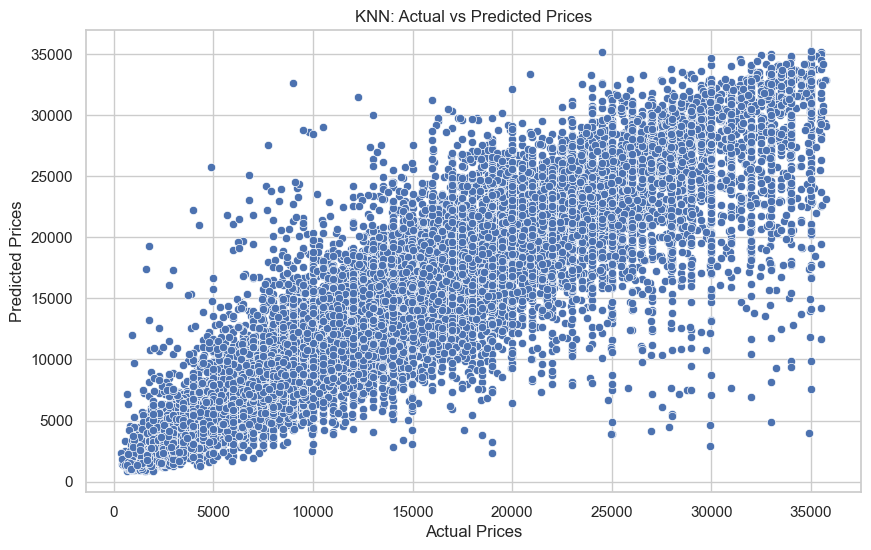

In [140]:
# KNN Model
print("Training KNN...")

# Model Training
knn = KNeighborsRegressor()
knn.fit(x_train, y_train)

# Cross-Validation
cv_score_knn = cross_val_score(knn, x_train, y_train, cv=5, scoring='neg_mean_squared_error')
mean_cv_rmse_knn = -cv_score_knn.mean()
cv_r2_knn = cross_val_score(knn, x_train, y_train, cv=5, scoring='r2').mean()
print(f"Cross-validation for KNN - RMSE: {mean_cv_rmse_knn}, R^2: {cv_r2_knn*100}")

# Predicting on train and test set
y_train_pred_knn = knn.predict(x_train)
y_val_pred_knn = knn.predict(x_val)

# Calculating metrics for KNN
train_rmse_knn = mean_squared_error(y_train, y_train_pred_knn, squared=False)
val_rmse_knn = mean_squared_error(y_val, y_val_pred_knn, squared=False)
train_r2_knn = r2_score(y_train, y_train_pred_knn)
val_r2_knn = r2_score(y_val, y_val_pred_knn)

train_mae_knn = mean_absolute_error(y_train, y_train_pred_knn)
val_mae_knn = mean_absolute_error(y_val, y_val_pred_knn)
train_mse_knn = mean_squared_error(y_train, y_train_pred_knn)
val_mse_knn = mean_squared_error(y_val, y_val_pred_knn)

# Print results for KNN
print(f"KNN:\n"
      f"    Train RMSE: {train_rmse_knn}, Validation RMSE: {val_rmse_knn}\n"
      f"    Train R^2: {train_r2_knn*100}, Validation R^2: {val_r2_knn*100}\n"
      f"    Train MAE: {train_mae_knn}, Validation MAE: {val_mae_knn}\n"
      f"    Train MSE: {train_mse_knn}, Validation MSE: {val_mse_knn}")

# Plotting Actual vs Predicted
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_val, y=y_val_pred_knn)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('KNN: Actual vs Predicted Prices')
plt.show()


#### Model 4: Random Forest Regressor

Training Random Forest...
Cross-validation for Random Forest - RMSE: 4442084.824169274, R^2: 82.19242086170573
Random Forest:
    Train RMSE: 815.60120625225, Validation RMSE: 2076.0495189125713
    Train R^2: 98.82489016261754, Validation R^2: 92.3378884910881
    Train MAE: 532.9246350688876, Validation MAE: 1378.3690850444355
    Train MSE: 665205.3276401252, Validation MSE: 4309981.604977119


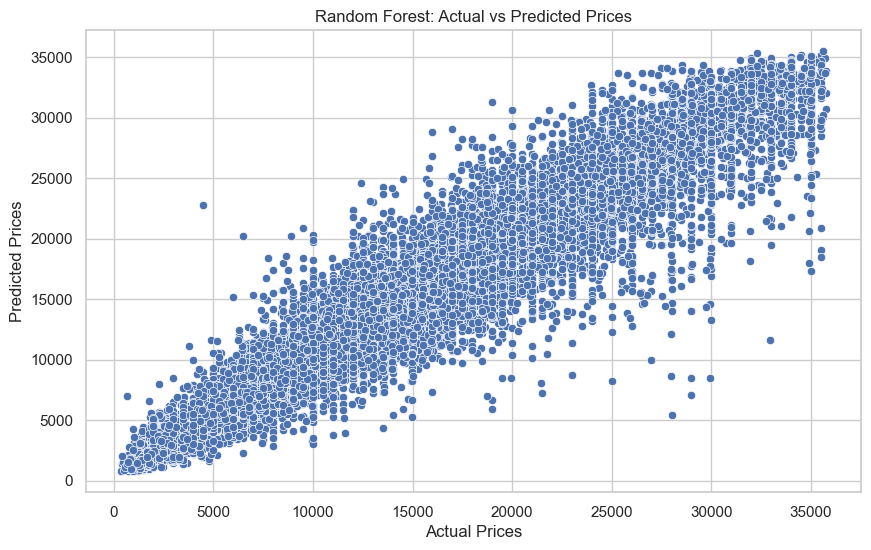

In [141]:
# Random Forest Model
print("Training Random Forest...")

# Model Training
rf = RandomForestRegressor(random_state=42)
rf.fit(x_train, y_train)

# Cross-Validation
cv_score_best = cross_val_score(rf, x_train, y_train, cv=5, scoring='neg_mean_squared_error')
mean_cv_rmse_best = -cv_score_best.mean()
cv_r2_best = cross_val_score(rf, x_train[:5000], y_train[:5000], cv=5, scoring='r2').mean()
print(f"Cross-validation for Random Forest - RMSE: {mean_cv_rmse_best}, R^2: {cv_r2_best*100}")

# Predicting on train and validation set
y_train_pred_rf = rf.predict(x_train)
y_val_pred_rf = rf.predict(x_val)

# Calculating metrics for Random Forest
train_rmse_rf = mean_squared_error(y_train, y_train_pred_rf, squared=False)
val_rmse_rf = mean_squared_error(y_val, y_val_pred_rf, squared=False)
train_r2_rf = r2_score(y_train, y_train_pred_rf)
val_r2_rf = r2_score(y_val, y_val_pred_rf)
train_mae_rf = mean_absolute_error(y_train, y_train_pred_rf)
val_mae_rf = mean_absolute_error(y_val, y_val_pred_rf)
train_mse_rf = mean_squared_error(y_train, y_train_pred_rf)
val_mse_rf = mean_squared_error(y_val, y_val_pred_rf)

# Print results for Random Forest
print(f"Random Forest:\n"
      f"    Train RMSE: {train_rmse_rf}, Validation RMSE: {val_rmse_rf}\n"
      f"    Train R^2: {train_r2_rf*100}, Validation R^2: {val_r2_rf*100}\n"
      f"    Train MAE: {train_mae_rf}, Validation MAE: {val_mae_rf}\n"
      f"    Train MSE: {train_mse_rf}, Validation MSE: {val_mse_rf}")

# Plotting Actual vs Predicted
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_val, y=y_val_pred_rf)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Random Forest: Actual vs Predicted Prices')
plt.show()


In [142]:
# Hyperparameter Tuning using Random Search - best model
rf_params = {
    'n_estimators': [100, 200, 300, 400], # Number of trees in random forest
    'max_depth': [10, 20, 30, 40],  # Maximum number of levels in tree
    'min_samples_split': [2, 5, 10], # Number of samples
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}
rf_random = RandomizedSearchCV(rf, rf_params, n_iter=20, cv=5, scoring='neg_mean_squared_error', random_state=42)
rf_random.fit(x_train[:5000], y_train[:5000])

print(f'Best Random Forest Params: {rf_random.best_params_}')

Best Random Forest Params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20, 'bootstrap': True}


#### Compare the RMSE, MAE/MSE and R square and find the best model

In [143]:
# Store model evaluation metrics
model_results = {
    'Model': ['Linear Regression', 'Decision Tree', 
              'KNN Regressor', 'Random Forest'],
    'RMSE': [val_rmse_lr, val_rmse_dt, 
             val_rmse_knn, val_rmse_rf],
    'R²': [val_r2_lr*100, val_r2_dt*100, 
           val_r2_knn*100, val_r2_rf*100],
    'MAE': [val_mae_lr, val_mae_dt, 
            val_mae_knn, val_mae_rf],
    'MSE': [val_mse_lr, val_mse_dt, 
            val_mse_knn, val_mse_rf],
}

# Create a DataFrame for comparison
comparison_df = pd.DataFrame(model_results)

# Display the Model Comparison Table
print("Model Comparison Table:")
print(comparison_df)

# Identify the best model based on the highest R² and the lowest MSE/MAE
best_model_idx = comparison_df['R²'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_model_mse = comparison_df.loc[best_model_idx, 'MSE']
best_model_mae = comparison_df.loc[best_model_idx, 'MAE']
best_model_r2 = comparison_df.loc[best_model_idx, 'R²']

# Print the summary of the best model
print("\nBest Model Summary:")
print(f"Best Model: {best_model_name}")
print(f"MSE: {best_model_mse}")
print(f"MAE: {best_model_mae}")
print(f"R²: {best_model_r2}")

Model Comparison Table:
               Model         RMSE         R²          MAE           MSE
0  Linear Regression  5317.107839  49.739826  4001.498258  2.827164e+07
1      Decision Tree  2643.084461  87.580757  1726.510134  6.985895e+06
2      KNN Regressor  3002.190585  83.976788  1889.476525  9.013148e+06
3      Random Forest  2076.049519  92.337888  1378.369085  4.309982e+06

Best Model Summary:
Best Model: Random Forest
MSE: 4309981.604977119
MAE: 1378.3690850444355
R²: 92.3378884910881


### Final Training and Testing (test-set) on Best Model - Random Forest

Training Best Random Forest Regressor Model...
Cross-validation for Best Tuned Random Forest Model - RMSE: 4073959.2315034596, R^2: 82.19242086170573
Best Tuned Random Forest Model Evaluation:
    RMSE: 2003.9944311875624, R^2: 92.89622813507833, MAE: 1333.9394091665613, MSE: 4015993.6802307623
    Training Time: 2886.047844648361 seconds
    Prediction Time: 10.714682817459106 seconds



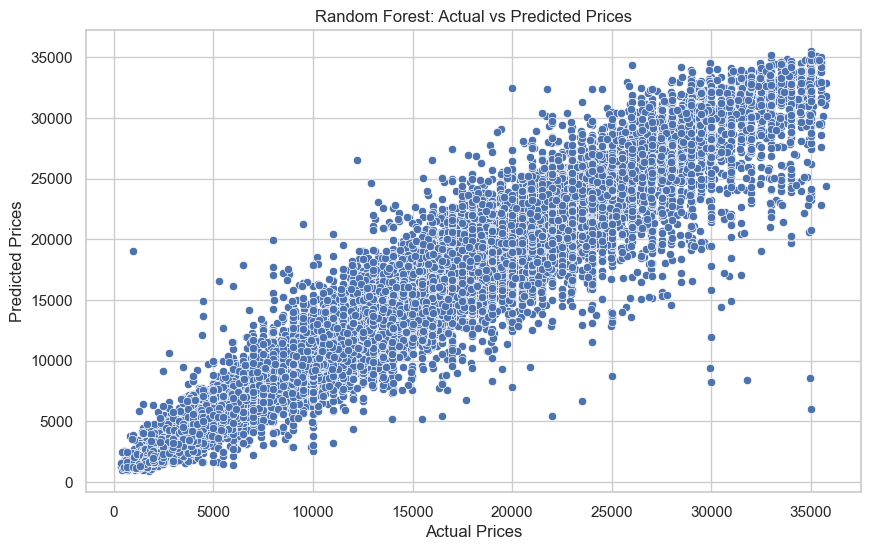

In [144]:
# Initialize and train the model with RandomizedSearchCV for hyperparameter tuning 
print("Training Best Random Forest Regressor Model...")
rf_model = RandomForestRegressor(random_state=42)
param_dist = {
    'n_estimators': [300],
    'max_depth': [20],
    'min_samples_split': [5],
    'min_samples_leaf': [1],
    'bootstrap': [True]
}

start_time = time.time()
rf_random = RandomizedSearchCV(rf_model, param_distributions=param_dist, n_iter=20, cv=5, scoring='neg_mean_squared_error', random_state=42)
rf_random.fit(x_train, y_train)   # Training Time: 10635.68 sec -> replace to subset (x_train[:5000], y_train[:5000]) for quick processing
end_time = time.time()

# Best model
best_rf_model = rf_random.best_estimator_

# Cross-Validation
cv_score_best = cross_val_score(best_rf_model, x_train, y_train, cv=5, scoring='neg_mean_squared_error')
mean_cv_rmse_best = -cv_score_best.mean()
cv_r2_best = cross_val_score(rf, x_train[:5000], y_train[:5000], cv=5, scoring='r2').mean()
print(f"Cross-validation for Best Tuned Random Forest Model - RMSE: {mean_cv_rmse_best}, R^2: {cv_r2_best*100}")

# Model Prediction
start_predict_time = time.time()
y_pred_rf = best_rf_model.predict(x_test)
end_predict_time = time.time()

# Model Evaluation
test_rmse_best_rf = mean_squared_error(y_test, y_pred_rf, squared=False)
test_r2_best_rf = r2_score(y_test, y_pred_rf)
test_mae_best_rf = mean_absolute_error(y_test, y_pred_rf)
test_mse_best_rf = mean_squared_error(y_test, y_pred_rf)

# Print results for Random Forest
print(f"Best Tuned Random Forest Model Evaluation:\n"
      f"    RMSE: {test_rmse_best_rf}, R^2: {test_r2_best_rf*100}, MAE: {test_mae_best_rf}, MSE: {test_mse_best_rf}\n"
      f"    Training Time: {end_time - start_time} seconds\n"
      f"    Prediction Time: {end_predict_time - start_predict_time} seconds\n")

# Plotting Actual vs Predicted
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Random Forest: Actual vs Predicted Prices')
plt.show()

In [145]:
# Save the Best trained Model
model_filename = f"car_price_prediction_model_{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.pkl"
with open(model_filename, 'wb') as file:
    pickle.dump(best_rf_model, file)
print(f"Model training complete. Best Model saved as {model_filename}")

Model training complete. Best Model saved as car_price_prediction_model_2025-01-18_23-41-07.pkl


#### Feature Importance: Identify which features contribute most to your model's predictions

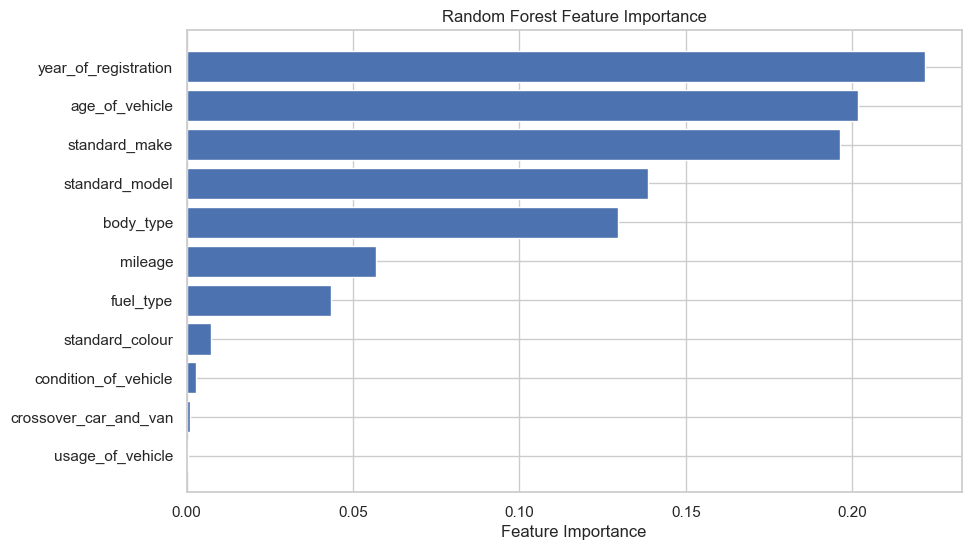

In [146]:
# Extract feature importances
importances = best_rf_model.feature_importances_
feature_names = x_train.columns 
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort and plot
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.show()

- This helps us understand which features are driving your model's predictions and can guide future feature engineering.

#### Residual Analysis: Analyze the residuals (errors) to identify patterns that the model might not have captured:

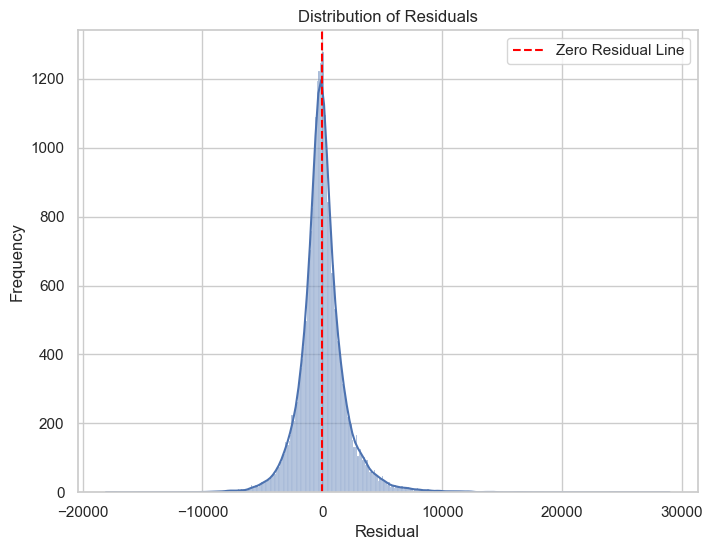

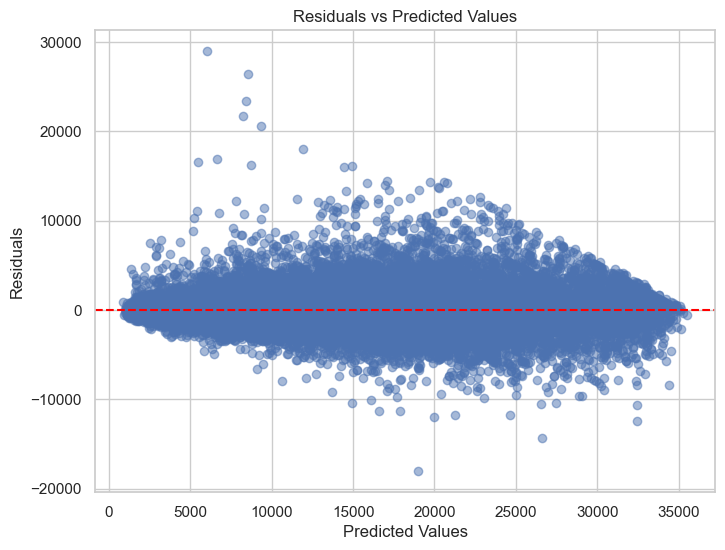

In [147]:
# Ensure y_pred is defined
y_pred = best_rf_model.predict(x_test)

# calculate the residuals
residuals = y_test - y_pred

# Plot residuals
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True)
plt.axvline(x=0, color='red', linestyle='--', label="Zero Residual Line")
plt.title('Distribution of Residuals')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Scatter plot of residuals vs. predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

- **Histogram of Residuals:** Should ideally follow a normal distribution centered around zero.
- **Residuals vs Predicted Values:** Random scatter indicates a good fit. Patterns may suggest model limitations or data issues.

## Model Prediction

#### Load the saved - best model

In [149]:
# Load the saved model
with open('car_price_prediction_model_2025-01-18_23-41-07.pkl', 'rb') as file:
    rf = pickle.load(file)

In [150]:
rf

RandomForestRegressor(max_depth=20, min_samples_split=5, n_estimators=300,
                      random_state=42)

#### Load the saved processing objects

In [151]:
# Load the preprocessing objects
with open("preprocessing_objects.pkl", "rb") as file:
    loaded_objects = pickle.load(file)

label_encoders = loaded_objects["label_encoders"]
scaler = loaded_objects["scaler"]

In [152]:
car_df_cleaned.head(7)

,mileage,standard_colour,standard_make,standard_model,year_of_registration,price,body_type,crossover_car_and_van,fuel_type,age_of_vehicle,condition_of_vehicle,usage_of_vehicle
1,108230.0,Blue,Jaguar,XF,2011,7000,Saloon,False,Diesel,14,OLD,HIGH
2,7800.0,Grey,SKODA,Yeti,2017,14000,SUV,False,Petrol,8,MID-AGE,LOW
3,45000.0,Brown,Vauxhall,Mokka,2016,7995,Hatchback,False,Diesel,9,MID-AGE,AVERAGE
4,64000.0,Grey,Land Rover,Range Rover Sport,2015,26995,SUV,False,Diesel,10,MID-AGE,HIGH
5,16000.0,Blue,Audi,S5,2017,29000,Convertible,False,Petrol,8,MID-AGE,AVERAGE
6,24075.0,Red,Vauxhall,Viva,2017,5861,Hatchback,False,Petrol,8,MID-AGE,AVERAGE
7,99000.0,Bronze,Land Rover,Range Rover,2013,24475,SUV,False,Diesel,12,OLD,HIGH


**Type 1: Prediction with older data** 

In [153]:
# Eg. 110000.0	Red	Peugeot	107	2009	2000	Hatchback	False	Petrol	15	OLD	HIGH
# Taking a sample data for prediction from our existing dataset
old_data = {
    "mileage": 110000.0,
    "standard_colour": "Red",
    "standard_make": "Peugeot",
    "standard_model": "107",
    "year_of_registration": 2009,
    "body_type": "Hatchback",
    "crossover_car_and_van": False,
    "fuel_type": "Petrol",
    "age_of_vehicle": 15,
    "condition_of_vehicle": "OLD",
    "usage_of_vehicle": "HIGH"
}

# Apply Label Encoding to categorical features
categorical_columns = ['standard_colour', 'standard_make', 'standard_model', 'body_type',
                       'fuel_type', 'condition_of_vehicle', 'usage_of_vehicle']

for col in categorical_columns:
    old_data[col] = label_encoders[col].transform([old_data[col]])[0]

# Convert to DataFrame
old_data_df = pd.DataFrame([old_data])

# Standardize numerical features
old_data_standardized = scaler.transform(old_data_df)

# Make predictions
predicted_price = rf.predict(old_data_standardized)

# Print the predicted price
print("Predicted Selling Price:", predicted_price[0])

Predicted Selling Price: 1714.665356743179


**Type 2: Prediction with New data**

In [154]:
# New data sample (aligned with our dataset structure)
new_data = {
    "mileage": 32002.0,
    "standard_colour": "Blue",
    "standard_make": "Audi",
    "standard_model": "A4 Avant",
    "year_of_registration": 2017,
    "body_type": "SUV",
    "crossover_car_and_van": True,
    "fuel_type": "Diesel",
    "age_of_vehicle": 7,
    "condition_of_vehicle": "NEW",
    "usage_of_vehicle": "LOW"
}

# Apply Label Encoding to categorical features
categorical_columns = ['standard_colour', 'standard_make', 'standard_model', 'body_type',
                       'fuel_type', 'condition_of_vehicle', 'usage_of_vehicle']

for col in categorical_columns:
    new_data[col] = label_encoders[col].transform([new_data[col]])[0]

# Convert new data into a DataFrame
new_data_df = pd.DataFrame([new_data])

# Standardize numerical features
new_data_standardized = scaler.transform(new_data_df)

# Make predictions on the standardized new data using the trained Random Forest model
predicted_price = rf.predict(new_data_standardized)

# Print the predicted price
print("Predicted Selling Price:", predicted_price[0])

Predicted Selling Price: 18396.1535323684


**Type 3: User Input Data Prediction**

- This code allows users to input car details like name, year, price, mileage, and fuel type to predict the selling price using a trained Random Forest model. 
- It processes categorical data, standardizes inputs, and predicts values.

In [157]:
def predict_car_price():
    """
    Predicts the selling price of a car based on user inputs and derived fields.

    Returns:
        float: The predicted selling price of the car.
    """
    # Get user inputs
    mileage = float(input("Enter mileage: "))
    standard_colour = input("Enter car color: ")
    standard_make = input("Enter car make: ")
    standard_model = input("Enter car model: ")
    year_of_registration = int(input("Enter year of registration: "))
    body_type = input("Enter body type: ")
    crossover_car_and_van = int(input("Is it a crossover (1 for Yes, 0 for No): "))
    fuel_type = input("Enter fuel type: ")

    # Automatic calculation of derived fields
    current_year = 2024  # Replace with dynamic calculation if needed
    age_of_vehicle = current_year - year_of_registration

    # Assign 'condition_of_vehicle' based on 'year_of_registration'
    if year_of_registration <= 2013:
        condition_of_vehicle = 'OLD'
    elif 2014 <= year_of_registration <= 2017:
        condition_of_vehicle = 'MID-AGE'
    else:
        condition_of_vehicle = 'NEW'

    # Assign 'usage_of_vehicle' based on 'mileage'
    if mileage < 15129.0:
        usage_of_vehicle = 'LOW'
    elif 15129.0 <= mileage <= 57525.0:
        usage_of_vehicle = 'AVERAGE'
    else:
        usage_of_vehicle = 'HIGH'

    # Create the data dictionary
    data_dict = {
        "mileage": mileage,
        "standard_colour": standard_colour,
        "standard_make": standard_make,
        "standard_model": standard_model,
        "year_of_registration": year_of_registration,
        "body_type": body_type,
        "crossover_car_and_van": crossover_car_and_van,
        "fuel_type": fuel_type,
        "age_of_vehicle": age_of_vehicle,
        "condition_of_vehicle": condition_of_vehicle,
        "usage_of_vehicle": usage_of_vehicle
    }

    # Apply Label Encoding to categorical features
    categorical_columns = ['standard_colour', 'standard_make', 'standard_model', 'body_type',
                           'fuel_type', 'condition_of_vehicle', 'usage_of_vehicle']

    for col in categorical_columns:
        data_dict[col] = label_encoders[col].transform([data_dict[col]])[0]

    # Convert new data into a DataFrame
    data_df = pd.DataFrame([data_dict])

    # Standardize numerical features
    pred_data_standardized = scaler.transform(data_df)

    # Make predictions on the standardized new data using the trained Random Forest model
    predicted_price = rf.predict(pred_data_standardized)

    # Return the predicted price
    return predicted_price[0]

# Prediction:
predicted_price = predict_car_price()
print("Predicted Selling Price:", predicted_price)

Enter mileage: 45000.0
Enter car color: Brown
Enter car make: Vauxhall
Enter car model: Mokka
Enter year of registration: 2016
Enter body type: Hatchback
Is it a crossover (1 for Yes, 0 for No): 0
Enter fuel type: Diesel
Predicted Selling Price: 8988.697858937154


In [160]:
### Sample Data: 45000.0	Brown	Vauxhall	Mokka	2016	Hatchback	False	Diesel	Price 7995
### Sample Data: 7800.0	Grey	SKODA	Yeti	2017	SUV	False	Petrol	Price 14000

In our example above, the actual price of the car is 7995 which is approx. close to the predicted price 8988. So our model is giving effective prediction.

## Conclusion:

- Understanding the dataset is essential for building accurate prediction models. By exploring it thoroughly, we uncovered insights that guided model development and helped identify patterns. Using machine learning, we leveraged these insights to make predictions and support data-driven decisions effectively.